# The July 2026 IACC Strategic Plan Draft, Read Against the IACC Publication Record

This notebook compares the **IACC Strategic Plan Working Draft (July 17, 2026)** with every document in
`iac/IACC_Publications/` (strategic plans 2009–2023, summaries of advances 2007–2023, reports to Congress,
portfolio analyses, letters) **linguistically**: how the draft is written, what words it favours, what it
stopped saying, how far its vocabulary and style sit from each earlier document, how much of it is
inherited text, and where it falls on the trends that run through the IACC record year by year.

Everything is computed locally. No API keys, no downloads. If the PDFs are absent (e.g. a fresh clone of the repository), the analysis runs entirely from the shipped text cache (`.pdf_cache/` + `cache_manifest.json`); with the PDFs present, everything is re-derived from source.

| Section | What it does |
| --- | --- |
| 1 | Inventory the corpus (series, year, variant, size) |
| 2 | Extract and clean text: running headers/footers, tables of contents and reference lists are stripped so they do not masquerade as prose |
| 3 | Per-document **style profile**: length, sentence and word shape, six readability indices, lexical diversity, passive voice, modality, hedging/boosting, nominalisation, acronyms, numerals |
| 4 | **Domain lexicon** tracker: person-first vs identity-first language, ASD vs autism, treatment vs services, causes, equity, governance, modal verbs |
| 5 | Where the draft sits: z-scores of the draft against the earlier strategic plans and against the whole corpus |
| 6 | **Keyness**: words and bigrams the draft over- and under-uses relative to prior plans (weighted log-odds with an informative Dirichlet prior + log-likelihood), plus vocabulary that is brand new or has disappeared |
| 7 | **Similarity and stylometry**: TF-IDF cosine to every earlier document, a 2-D map, and Burrows' Delta on function words |
| 8 | **Text reuse**: how much of the draft is verbatim 8-word sequences from earlier IACC documents, compared with how much each earlier plan inherited from its predecessors; longest shared passages |
| 9 | **Over the years**: style and lexicon trends by series with the draft placed at 2026; terms rising and falling across the record and whether the draft continues or reverses them |
| 10 | Inside the draft: the same measures per Part/section, with each section's nearest earlier document and its share of novel text |
| 11 | Export CSVs, figures and a markdown report |
| 12 | Smoke tests of the measurement code |

**Caveats.** Sentence splitting, syllable counting and passive-voice detection are heuristic; they are applied
identically to every document, so comparisons are fair even where absolute values are approximate. Easy-read
and at-a-glance editions and very short letters are inventoried but excluded from the comparisons (different
register; too short for stable statistics). Reference lists and member rosters that follow a "References"
heading are removed before measuring.

In [1]:
# # One-time installs. Uncomment whatever the capability report (next cell) says is missing.
# %pip install "pymupdf>=1.24" "scikit-learn>=1.3" "pandas>=2.0" "numpy>=1.24" "matplotlib>=3.7" "scipy>=1.10"
# %pip install "pypdf>=4.2" "pdfplumber>=0.11"   # extra PDF fallbacks

In [2]:
from __future__ import annotations

import hashlib
import importlib
import json
import math
import re
import shutil
import subprocess
import sys
import time
import warnings
from collections import Counter, defaultdict
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Callable, Iterable, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from scipy.stats import rankdata
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_similarity

try:  # keeps the notebook importable as a plain script
    from IPython.display import Markdown, display
except ImportError:
    display = print
    Markdown = str

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 90)


def _try_import(*names: str):
    for name in names:
        try:
            return importlib.import_module(name)
        except Exception:
            continue
    return None


FITZ = _try_import("pymupdf", "fitz")
PYPDF = _try_import("pypdf", "PyPDF2")
PDFPLUMBER = _try_import("pdfplumber")
PDFTOTEXT_BIN = shutil.which("pdftotext")


def capability_report() -> pd.DataFrame:
    rows = [
        ("PDF text: pymupdf", FITZ is not None, "fastest; also reads the PDF outline used for section splits"),
        ("PDF text: pypdf", PYPDF is not None, "fallback, pure python"),
        ("PDF text: pdfplumber", PDFPLUMBER is not None, "fallback"),
        ("PDF text: pdftotext CLI", PDFTOTEXT_BIN is not None, "fallback, poppler binary"),
        ("scikit-learn / scipy / matplotlib", True, "always required"),
    ]
    return pd.DataFrame(rows, columns=["capability", "available", "notes"])


print(f"python {sys.version.split()[0]}  |  numpy {np.__version__}  |  pandas {pd.__version__}")
if not any((FITZ, PYPDF, PDFPLUMBER, PDFTOTEXT_BIN)):
    print("\nNo PDF text extractor found. Run the install cell above (pymupdf recommended).")
capability_report()

python 3.11.15  |  numpy 2.4.4  |  pandas 2.3.3


,capability,available,notes
0,PDF text: pymupdf,True,fastest; also reads the PDF outline used for section splits
1,PDF text: pypdf,True,"fallback, pure python"
2,PDF text: pdfplumber,True,fallback
3,PDF text: pdftotext CLI,True,"fallback, poppler binary"
4,scikit-learn / scipy / matplotlib,True,always required


## Configuration

`draft_path` is the document under study; `publications_dir` is the archive it is compared with. The other
settings are analysis knobs with sensible defaults. `min_words` decides which documents are long enough to
enter the comparisons (everything is still inventoried).

In [3]:
NOTEBOOK_DIR = Path.cwd()


@dataclass
class Config:
    # --- inputs / outputs ---
    draft_path: Path = NOTEBOOK_DIR / "iac" / "IACC Strategic Plan Working Draft July 17.pdf"
    publications_dir: Path = NOTEBOOK_DIR / "iac" / "IACC_Publications"
    output_dir: Path = NOTEBOOK_DIR / "outputs" / "iacc_linguistic"
    cache_dir: Path = NOTEBOOK_DIR / ".pdf_cache" / "iacc_linguistic"
    use_cache: bool = True

    # --- the document under study ---
    draft_year: int = 2026
    draft_id: str = "SP-2026-DRAFT"
    focus_series: str = "strategic-plan"  # the series the draft belongs to

    # --- which documents enter the comparisons ---
    exclude_variants: tuple[str, ...] = ("easy_read", "at_a_glance")
    min_words: int = 2000  # shorter documents are inventoried but not compared

    # --- cleaning ---
    trim_references: bool = True
    ref_page_density: float = 70.0  # citation markers per 1,000 words above which a page is a reference list
    ref_page_min_words: int = 50
    running_line_share: float = 0.20  # a line on >= this share of pages is a running header/footer

    # --- measures ---
    mattr_window: int = 500  # moving-average type-token ratio window
    mfw_count: int = 150  # most-frequent words for Burrows' Delta
    keyness_alpha0: float = 1000.0  # strength of the Dirichlet prior in the log-odds keyness
    keyness_min_count: int = 5
    keyness_top: int = 30
    shingle_n: int = 8  # word n-gram length for text reuse
    trend_min_docs: int = 10  # a term must appear in this many documents to be trended
    trend_min_rate: float = 0.5  # ... and average at least this many uses per 10,000 words
    proper_noun_share: float = 0.7  # a term written Title-Case this often is a name (person, agency, place) and is skipped in trend lists
    trend_top: int = 25
    section_min_words: int = 300
    section_toc_level: int = 1  # PDF outline depth used to split the draft into sections

    # --- presentation ---
    figure_dpi: int = 130
    random_state: int = 42


CFG = Config()

# --- cache-only mode -----------------------------------------------------------
# This repository ships the extracted text of every PDF (cache_dir, plus a
# cache_manifest.json mapping each document to its content hash). When the PDFs
# are absent - e.g. a fresh clone - the whole analysis runs from the cache.
MANIFEST_PATH = CFG.cache_dir / "cache_manifest.json"
MANIFEST: dict = {}
if MANIFEST_PATH.exists():
    try:
        MANIFEST = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
    except (OSError, json.JSONDecodeError):
        MANIFEST = {}


def manifest_sha(for_path: Any) -> str:
    """sha256 of a document from the cache manifest, matched by archive-relative path suffix."""
    p = str(for_path).replace("\\", "/")
    for k, v in MANIFEST.get("files", {}).items():
        if p.endswith(k):
            return v["sha256"]
    draft_meta = MANIFEST.get("draft", {})
    if draft_meta and p.endswith(draft_meta.get("name", "\x00")):
        return draft_meta.get("sha256", "")
    return ""


if not CFG.draft_path.exists():  # fall back to any PDF in iac/ that is not part of the archive
    candidates = [p for p in (NOTEBOOK_DIR / "iac").glob("*.pdf") if p.is_file()]
    if candidates:
        CFG.draft_path = sorted(candidates)[0]
CACHE_ONLY = not CFG.draft_path.exists()
if CACHE_ONLY and not manifest_sha(CFG.draft_path):
    raise FileNotFoundError(f"draft PDF not found: {CFG.draft_path} (and no cache-manifest entry)")
if not CFG.publications_dir.is_dir() and not MANIFEST:
    raise FileNotFoundError(f"publications folder not found: {CFG.publications_dir} (and no cache manifest)")

CFG.output_dir.mkdir(parents=True, exist_ok=True)
CFG.cache_dir.mkdir(parents=True, exist_ok=True)
FIGURES: list[Path] = []


def savefig(name: str) -> None:
    """Save the current figure into the output folder and show it."""
    path = CFG.output_dir / f"{name}.png"
    plt.savefig(path, dpi=CFG.figure_dpi, bbox_inches="tight")
    FIGURES.append(path)
    plt.show()


print(f"draft            : {CFG.draft_path.name}")
print(f"publications_dir : {CFG.publications_dir}")
print(f"output_dir       : {CFG.output_dir}")
print(f"cache_dir        : {CFG.cache_dir}")
print(f"mode             : {'cache-only (running from shipped text cache)' if CACHE_ONLY else 'PDFs + cache'}")

draft            : IACC Strategic Plan Working Draft July 17.pdf
publications_dir : /Volumes/two-terry/asd_ei_review/iac/IACC_Publications
output_dir       : /Volumes/two-terry/asd_ei_review/outputs/iacc_linguistic
cache_dir        : /Volumes/two-terry/asd_ei_review/.pdf_cache/iacc_linguistic


## 1. Corpus inventory

Every PDF under `publications_dir` is listed with its series (the top-level folder), year (folder, `INDEX.csv`,
or file name, in that order), and variant (`full`, `easy_read`, `at_a_glance`). The draft is added as the
newest member of the strategic-plan series.

In [4]:
from pathlib import PurePosixPath

SERIES_SHORT = {
    "strategic-plan": "SP",
    "summary-of-advances": "SOA",
    "report-to-congress": "RTC",
    "portfolio-analysis": "PA",
    "international-portfolio-analysis": "IPA",
    "publications-analysis": "PUBA",
    "autism": "USPSTF",
    "general": "LETTER",
}
SERIES_LABEL = {
    "strategic-plan": "Strategic Plan",
    "summary-of-advances": "Summary of Advances",
    "report-to-congress": "Report to Congress",
    "portfolio-analysis": "Portfolio Analysis",
    "international-portfolio-analysis": "Intl. Portfolio Analysis",
    "publications-analysis": "Publications Analysis",
    "autism": "USPSTF Report",
    "general": "Letters & Statements",
}
SERIES_COLOR = {
    "strategic-plan": "#d62728",
    "summary-of-advances": "#1f77b4",
    "report-to-congress": "#2ca02c",
    "portfolio-analysis": "#ff7f0e",
    "international-portfolio-analysis": "#e377c2",
    "publications-analysis": "#8c564b",
    "autism": "#7f7f7f",
    "general": "#bcbd22",
}
YEAR_RE = re.compile(r"(?<!\d)((?:19|20)\d{2})(?!\d)")


def detect_variant(name: str) -> str:
    flat = re.sub(r"[^a-z]", "", name.lower())
    if "easyread" in flat:
        return "easy_read"
    if "ataglance" in flat:
        return "at_a_glance"
    return "full"


def build_inventory(cfg: Config) -> pd.DataFrame:
    index_path = cfg.publications_dir / "INDEX.csv"
    index = pd.read_csv(index_path) if index_path.exists() else pd.DataFrame(columns=["category", "year", "filename", "source_url"])
    index_lookup = {(str(r.category), str(r.filename)): r for r in index.itertuples(index=False)}

    # Documents come from the PDFs on disk when present; otherwise from the cache
    # manifest (repository mode: the extracted text ships in cache_dir, keyed by hash).
    disk_pdfs = [p for p in sorted(cfg.publications_dir.rglob("*.pdf")) if p.is_file() and not p.name.startswith(".")] if cfg.publications_dir.is_dir() else []
    if disk_pdfs:
        entries = [(p, p.relative_to(cfg.publications_dir).as_posix(), p.stat().st_size) for p in disk_pdfs]
    else:
        entries = [(cfg.publications_dir / rel, rel, meta.get("bytes", 0)) for rel, meta in sorted(MANIFEST.get("files", {}).items())]

    rows = []
    for path, rel_str, nbytes in entries:
        rel = PurePosixPath(rel_str)
        series = rel.parts[0] if len(rel.parts) > 1 else "general"
        year = None
        for part in rel.parts[1:-1]:
            if YEAR_RE.fullmatch(part):
                year = int(part)
        meta = index_lookup.get((series, path.name))
        if year is None and meta is not None and pd.notna(meta.year):
            year = int(meta.year)
        if year is None:
            found = YEAR_RE.findall(path.name)
            year = int(found[0]) if found else None
        rows.append(
            {
                "series": series,
                "series_short": SERIES_SHORT.get(series, series[:6].upper()),
                "year": year,
                "variant": detect_variant(path.name),
                "is_draft": False,
                "file_name": path.name,
                "path": str(path),
                "source_url": getattr(meta, "source_url", "") if meta is not None else "",
                "bytes": nbytes,
            }
        )
    rows.append(
        {
            "series": cfg.focus_series,
            "series_short": SERIES_SHORT.get(cfg.focus_series, "SP"),
            "year": cfg.draft_year,
            "variant": "draft",
            "is_draft": True,
            "file_name": cfg.draft_path.name,
            "path": str(cfg.draft_path),
            "source_url": "",
            "bytes": cfg.draft_path.stat().st_size if cfg.draft_path.exists() else MANIFEST.get("draft", {}).get("bytes", 0),
        }
    )
    df = pd.DataFrame(rows)

    # Readable, unique identifiers: SP-2023, SP-2023-ER, RTC-2009, LETTER-2011a ...
    suffix = {"easy_read": "-ER", "at_a_glance": "-AAG", "draft": "-DRAFT", "full": ""}
    base_ids = [f"{r.series_short}-{r.year if r.year is not None else 'undated'}{suffix[r.variant]}" for r in df.itertuples()]
    counts = Counter(base_ids)
    seen: Counter = Counter()
    ids = []
    for base in base_ids:
        if counts[base] == 1:
            ids.append(base)
        else:
            ids.append(f"{base}{'abcdefghij'[seen[base]]}")
            seen[base] += 1
    df.insert(0, "doc_id", ids)
    df.loc[df["is_draft"], "doc_id"] = cfg.draft_id
    return df.sort_values(["series", "year", "variant", "file_name"]).reset_index(drop=True)


INVENTORY = build_inventory(CFG)
print(f"{len(INVENTORY)} documents ({INVENTORY['is_draft'].sum()} draft + {(~INVENTORY['is_draft']).sum()} archive)")
display(INVENTORY.groupby("series").agg(documents=("doc_id", "size"), first_year=("year", "min"), last_year=("year", "max")))
display(INVENTORY[["doc_id", "series", "year", "variant", "file_name", "bytes"]])

61 documents (1 draft + 60 archive)


,documents,first_year,last_year
series,,,
autism,1,2016,2016
general,8,2009,2014
international-portfolio-analysis,1,2016,2016
portfolio-analysis,12,2008,2022
publications-analysis,1,2012,2012
report-to-congress,7,2009,2023
strategic-plan,10,2009,2026
summary-of-advances,21,2007,2023


,doc_id,series,year,variant,file_name,bytes
0,USPSTF-2016,autism,2016,full,uspstf_report_to_congress_2016.pdf,384734
1,LETTER-2009,general,2009,full,2009_letter_to_nvac.pdf,106764
2,LETTER-2011a,general,2011,full,iacc_response_letter_sebelius_wandering_032311.pdf,36726
3,LETTER-2011b,general,2011,full,letter_seclusion_restraint_090711.pdf,153348
4,LETTER-2011c,general,2011,full,letter_wandering_020911.pdf,136695
...,...,...,...,...,...,...
56,SOA-2021,summary-of-advances,2021,full,summary_of_advances_2021.pdf,1316223
57,SOA-2022-ER,summary-of-advances,2022,easy_read,summary_of_advances_2022_easy_read.pdf,1543905
58,SOA-2022,summary-of-advances,2022,full,summary_of_advances_2022.pdf,10816456
59,SOA-2023-ER,summary-of-advances,2023,easy_read,summary_of_advances_2023_easy_read.pdf,274393


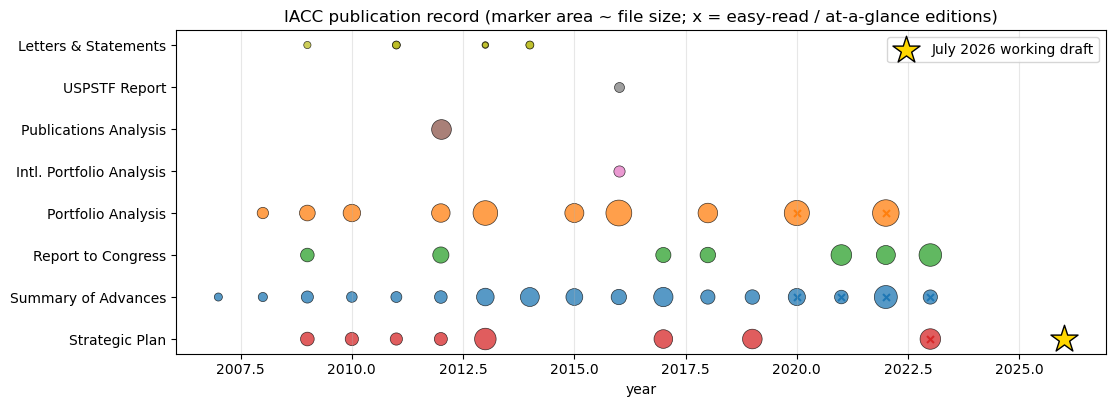

In [5]:
fig, ax = plt.subplots(figsize=(12, 4.2))
order = [s for s in SERIES_LABEL if s in set(INVENTORY["series"])]
for i, series in enumerate(order):
    sub = INVENTORY[(INVENTORY["series"] == series) & (INVENTORY["variant"] == "full")]
    ax.scatter(sub["year"], [i] * len(sub), s=np.sqrt(sub["bytes"]) / 12, color=SERIES_COLOR[series], alpha=0.75, edgecolor="black", linewidth=0.5)
    sub = INVENTORY[(INVENTORY["series"] == series) & (INVENTORY["variant"].isin(CFG.exclude_variants))]
    ax.scatter(sub["year"], [i] * len(sub), s=25, marker="x", color=SERIES_COLOR[series])
draft_row = INVENTORY[INVENTORY["is_draft"]].iloc[0]
ax.scatter([draft_row["year"]], [order.index(draft_row["series"])], marker="*", s=420, color="gold", edgecolor="black", zorder=5, label="July 2026 working draft")
ax.set_yticks(range(len(order)))
ax.set_yticklabels([SERIES_LABEL[s] for s in order])
ax.set_xlabel("year")
ax.set_title("IACC publication record (marker area ~ file size; x = easy-read / at-a-glance editions)")
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="upper right")
savefig("01_corpus_timeline")

## 2. Text extraction and cleaning

Text is extracted page by page (pymupdf first, then fallbacks) together with the PDF outline, and cached by
file hash. Before any measuring, each document is cleaned:

- **running headers and footers** - any line (digits ignored) that recurs on at least `running_line_share` of the pages;
- **table-of-contents lines** (dot leaders), bare page numbers, `[PMID: ...]` tags, URLs and DOIs;
- **reference lists** - any page whose density of bibliographic markers (author initials, "et al", DOI/PMID,
  volume(issue):page) exceeds `ref_page_density` per 1,000 words is dropped; this catches the per-chapter reference
  lists of the 2012 and 2013 plans as well as trailing bibliographies. In addition, everything from a trailing
  "References" heading onwards (outline entry or standalone line in the latter part of the document) is dropped when
  that tail is verifiably citation-dense, which also removes the section headings inside long reference lists;
- **hyphenation** at line ends is repaired using the document's own vocabulary (`develop-` + `ment` is joined,
  `social-` + `communication` keeps its hyphen if that compound occurs elsewhere).

Lines are then re-flowed into prose: bullets and headings start new sentences so that they do not merge into
multi-hundred-word "sentences".

In [6]:
CACHE_VERSION = 2
LIGATURES = {
    "\ufb00": "ff", "\ufb01": "fi", "\ufb02": "fl", "\ufb03": "ffi", "\ufb04": "ffl",
    "\u2018": "'", "\u2019": "'", "\u201c": '"', "\u201d": '"', "\u00ad": "", "\x00": " ",
}


def file_sha256(path: Path, block: int = 1 << 20) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(block), b""):
            digest.update(chunk)
    return digest.hexdigest()


def _pages_pymupdf(path: Path) -> dict:
    doc = FITZ.open(path)
    try:
        pages = [page.get_text("text") for page in doc]
        toc = [[int(lvl), str(title), int(pg)] for lvl, title, pg in (doc.get_toc() or [])]
        meta = dict(doc.metadata or {})
    finally:
        doc.close()
    return {"pages": pages, "toc": toc, "title": meta.get("title") or "", "created": meta.get("creationDate") or ""}


def _pages_pypdf(path: Path) -> dict:
    reader = PYPDF.PdfReader(str(path))
    pages = [(page.extract_text() or "") for page in reader.pages]
    title = ""
    try:
        title = str((reader.metadata or {}).get("/Title") or "")
    except Exception:
        pass
    return {"pages": pages, "toc": [], "title": title, "created": ""}


def _pages_pdfplumber(path: Path) -> dict:
    with PDFPLUMBER.open(str(path)) as pdf:
        pages = [page.extract_text() or "" for page in pdf.pages]
        title = str((pdf.metadata or {}).get("Title") or "")
    return {"pages": pages, "toc": [], "title": title, "created": ""}


def _pages_pdftotext(path: Path) -> dict:
    result = subprocess.run([PDFTOTEXT_BIN, "-q", str(path), "-"], capture_output=True, timeout=300)
    pages = result.stdout.decode("utf-8", errors="replace").split("\x0c")
    return {"pages": pages, "toc": [], "title": "", "created": ""}


PDF_BACKENDS: list[tuple[str, Callable[[Path], dict], Callable[[], bool]]] = [
    ("pymupdf", _pages_pymupdf, lambda: FITZ is not None),
    ("pypdf", _pages_pypdf, lambda: PYPDF is not None),
    ("pdfplumber", _pages_pdfplumber, lambda: PDFPLUMBER is not None),
    ("pdftotext", _pages_pdftotext, lambda: PDFTOTEXT_BIN is not None),
]


def extract_pages(path: Path, cfg: Config) -> dict:
    """Raw page texts + outline for one PDF, cached by content hash. Never raises.

    When the PDF itself is absent (repository clone without the PDFs), the sha256 is
    looked up in the cache manifest and the shipped cached extraction is used.
    """
    record: dict[str, Any] = {"path": str(path), "sha256": "", "backend": "", "pages": [], "toc": [], "title": "", "created": "", "error": "", "from_cache": False}
    try:
        sha = file_sha256(path)
    except OSError as exc:
        sha = manifest_sha(path)
        if not sha:
            record["error"] = f"unreadable: {exc} (and no cache-manifest entry)"
            return record
    record["sha256"] = sha
    cache_file = cfg.cache_dir / f"{sha}.json"
    if cfg.use_cache and cache_file.exists():
        try:
            cached = json.loads(cache_file.read_text(encoding="utf-8"))
            if cached.get("cache_version") == CACHE_VERSION:
                record.update({k: cached[k] for k in ("backend", "pages", "toc", "title", "created")})
                record["from_cache"] = True
                return record
        except (OSError, json.JSONDecodeError, KeyError):
            pass
    if not path.exists():
        record["error"] = f"PDF missing and no cached extraction: {path.name}"
        return record
    attempts = []
    for name, fn, ok in PDF_BACKENDS:
        if not ok():
            continue
        try:
            out = fn(path)
        except Exception as exc:
            attempts.append(f"{name}: {type(exc).__name__}: {exc}")
            continue
        if any(p.strip() for p in out["pages"]):
            record.update(out)
            record["backend"] = name
            break
        attempts.append(f"{name}: no text layer")
    if not record["backend"]:
        record["error"] = "; ".join(attempts) or "no PDF backend installed"
        return record
    if cfg.use_cache:
        try:
            payload = {k: record[k] for k in ("backend", "pages", "toc", "title", "created")}
            payload["cache_version"] = CACHE_VERSION
            cache_file.write_text(json.dumps(payload), encoding="utf-8")
        except OSError:
            pass
    return record
    record["sha256"] = sha
    cache_file = cfg.cache_dir / f"{sha}.json"
    if cfg.use_cache and cache_file.exists():
        try:
            cached = json.loads(cache_file.read_text(encoding="utf-8"))
            if cached.get("cache_version") == CACHE_VERSION:
                record.update({k: cached[k] for k in ("backend", "pages", "toc", "title", "created")})
                record["from_cache"] = True
                return record
        except (OSError, json.JSONDecodeError, KeyError):
            pass
    attempts = []
    for name, fn, ok in PDF_BACKENDS:
        if not ok():
            continue
        try:
            out = fn(path)
        except Exception as exc:
            attempts.append(f"{name}: {type(exc).__name__}: {exc}")
            continue
        if any(p.strip() for p in out["pages"]):
            record.update(out)
            record["backend"] = name
            break
        attempts.append(f"{name}: no text layer")
    if not record["backend"]:
        record["error"] = "; ".join(attempts) or "no PDF backend installed"
        return record
    if cfg.use_cache:
        try:
            payload = {k: record[k] for k in ("backend", "pages", "toc", "title", "created")}
            payload["cache_version"] = CACHE_VERSION
            cache_file.write_text(json.dumps(payload), encoding="utf-8")
        except OSError:
            pass
    return record

In [7]:
REF_HEADING_RE = re.compile(r"^\s*(?:references|bibliography|works cited|endnotes|literature cited|reference list)\s*[:.]?\s*$", re.I)
REF_TITLE_RE = re.compile(r"\b(?:references|bibliography|endnotes|works cited)\b", re.I)
# Bibliographic markers: 'et al', DOI/PMID/URL, Vancouver author initials ('Towle PO,'), APA initials ('Smith, J.'),
# volume(issue):page and year;volume patterns. Bare years are deliberately excluded - funding tables are full of them.
CITATION_RE = re.compile(
    r"\bet al\b|\bdoi\b|\bpmid\b|https?://|\b[A-Z][a-z]+ [A-Z]{1,3}[,.;]|\b[A-Z][a-z]+, [A-Z]\.|\b\d{1,4}\s*\(\d{1,3}\)\s*:\s*\d|\b(?:19|20)\d{2}\s*;\s*\d",
    re.I,
)
DOT_LEADER_RE = re.compile(r"\.{4,}|(?:\. ){4,}")
PAGE_NUMBER_RE = re.compile(r"^\s*(?:page\s+)?\d{1,4}(?:\s*(?:of|/)\s*\d{1,4})?\s*$|^\s*[ivxlc]{1,6}\s*$", re.I)
INLINE_JUNK_RE = re.compile(r"\[\s*PMID:?\s*\d+\s*\]|\bhttps?://\S+|\bwww\.\S+|\bdoi:\s*\S+", re.I)
WORD_RE = re.compile(r"[A-Za-z]+(?:['\-][A-Za-z]+)*")


def citation_density(text: str) -> float:
    words = len(WORD_RE.findall(text))
    return len(CITATION_RE.findall(text)) / max(1, words) * 1000


def find_reference_cut(pages: list[str], toc: list, min_position: float = 0.4) -> tuple[int | None, str]:
    """1-based page where the reference list starts, or None. Verified by citation density."""
    n = len(pages)
    if n < 6:
        return None, "too_short"
    floor = int(n * min_position)
    candidates = [pg for _lvl, title, pg in toc if pg >= floor + 1 and pg <= n and REF_TITLE_RE.search(title)]
    for i in range(floor, n):
        if any(REF_HEADING_RE.match(line) for line in pages[i].splitlines()):
            candidates.append(i + 1)
            break
    if not candidates:
        return None, "no_heading"
    cut = min(candidates)
    before = citation_density("\n".join(pages[: cut - 1]))
    after = citation_density("\n".join(pages[cut - 1 :]))
    if after >= 40 and after >= 3 * max(before, 1e-9):
        return cut, "verified"
    return None, f"unverified(before={before:.0f},after={after:.0f})"


def reference_pages(pages: list[str], cfg: Config) -> set[int]:
    """1-based pages that are themselves citation lists (per-chapter reference lists, endnotes)."""
    return {
        i + 1
        for i, page in enumerate(pages)
        if len(WORD_RE.findall(page)) >= cfg.ref_page_min_words and citation_density(page) >= cfg.ref_page_density
    }


def running_line_keys(pages: list[str], share: float) -> set[str]:
    counts: Counter = Counter()
    for page in pages:
        seen = set()
        for line in page.splitlines():
            key = re.sub(r"\s+", " ", re.sub(r"\d+", "#", line.strip().lower()))
            if 4 <= len(key) <= 140 and key not in seen:
                seen.add(key)
                counts[key] += 1
    threshold = max(3, int(math.ceil(share * len(pages))))
    return {key for key, c in counts.items() if c >= threshold}


def _line_key(line: str) -> str:
    return re.sub(r"\s+", " ", re.sub(r"\d+", "#", line.strip().lower()))


def smart_dehyphenate(text: str) -> str:
    """Join words broken at line ends, unless the hyphenated compound itself occurs elsewhere."""
    vocab = {w.lower() for w in re.findall(r"[A-Za-z]+(?:-[A-Za-z]+)*", re.sub(r"\w+-\n\w+", " ", text))}

    def fix(match: re.Match) -> str:
        a, b = match.group(1), match.group(2)
        if (a + b).lower() in vocab:
            return a + b
        if f"{a}-{b}".lower() in vocab:
            return f"{a}-{b}"
        return a + b

    return re.sub(r"(\w+)-\n(\w+)", fix, text)


def clean_pages(pages: list[str], toc: list, cfg: Config) -> tuple[list[str], dict]:
    """Strip boilerplate from every page; returns cleaned pages (same length) and a cleaning summary."""
    n = len(pages)
    for src, dst in LIGATURES.items():
        pages = [p.replace(src, dst) for p in pages]
    cut, cut_status = (find_reference_cut(pages, toc) if cfg.trim_references else (None, "disabled"))
    ref_pages = reference_pages(pages, cfg) if cfg.trim_references else set()
    dropped = {p for p in range(1, n + 1) if (cut is not None and p >= cut) or p in ref_pages}
    running = running_line_keys(pages, cfg.running_line_share)
    cleaned: list[str] = []
    removed_running = 0
    for i, page in enumerate(pages):
        if i + 1 in dropped:
            cleaned.append("")
            continue
        kept = []
        for line in page.splitlines():
            if not line.strip():
                kept.append("")
                continue
            if _line_key(line) in running:
                removed_running += 1
                continue
            if DOT_LEADER_RE.search(line) or PAGE_NUMBER_RE.match(line):
                continue
            kept.append(INLINE_JUNK_RE.sub(" ", line))
        cleaned.append(smart_dehyphenate("\n".join(kept)))
    words_in = sum(len(WORD_RE.findall(p)) for p in pages)
    words_out = sum(len(WORD_RE.findall(p)) for p in cleaned)
    info = {
        "n_pages": n,
        "n_pages_kept": n - len(dropped),
        "ref_cut_page": cut,
        "ref_cut_status": cut_status,
        "ref_pages_dropped": len(dropped),
        "running_lines": sorted(running, key=len, reverse=True)[:5],
        "running_lines_removed": removed_running,
        "words_raw": words_in,
        "words_clean": words_out,
    }
    return cleaned, info


BULLET_RE = re.compile(r"^\s*(?:[\u2022\u25aa\u25cf\u25cb\u25e6\u25a0\u25a1\u2023\u25ba\u25b6\u2713\u2714\*]+|[-\u2013\u2014](?=\s))\s*")


def is_heading(line: str) -> bool:
    words = line.split()
    if not words or len(words) > 14:
        return False
    if line.rstrip()[-1] in ".!?;,":
        return False
    capitalised = sum(1 for w in words if not w[0].isalpha() or w[0].isupper())
    return capitalised / len(words) >= 0.6


def lines_to_prose(page_text: str) -> str:
    """Re-flow PDF lines into sentences; bullets and headings start their own sentence."""
    out: list[str] = []
    buf: list[str] = []

    def flush() -> None:
        if buf:
            s = " ".join(buf).strip().rstrip(":;,")
            if s and s[-1] not in ".!?":
                s += "."
            if s:
                out.append(s)
            buf.clear()

    for raw in page_text.splitlines():
        line = raw.strip()
        if not line:
            flush()
            continue
        m = BULLET_RE.match(line)
        if m and m.end() > 0:
            flush()
            line = line[m.end() :].strip()
            if line:
                buf.append(line)
            continue
        # A heading never continues an unfinished sentence, so a capitalised line that follows
        # an open line is treated as an ordinary wrapped line.
        if is_heading(line) and (not buf or buf[-1].rstrip()[-1] in ".!?:;"):
            flush()
            out.append(line.rstrip(":") + ".")
            continue
        buf.append(line)
    flush()
    return re.sub(r"[ \t\u00a0]+", " ", " ".join(out)).strip()


def pages_to_prose(pages: list[str]) -> str:
    return "\n\n".join(p for p in (lines_to_prose(page) for page in pages) if p)

In [8]:
def load_corpus(inventory: pd.DataFrame, cfg: Config) -> tuple[pd.DataFrame, dict, dict, dict]:
    """Extract, clean and re-flow every document. Returns a frame plus per-doc pages/outline/cleaning info."""
    started = time.perf_counter()
    rows, pages_clean, tocs, clean_info = [], {}, {}, {}
    for r in inventory.itertuples(index=False):
        rec = extract_pages(Path(r.path), cfg)
        if rec["error"]:
            rows.append({"doc_id": r.doc_id, "backend": "", "error": rec["error"], "n_pages": 0, "n_pages_kept": 0, "ref_cut_page": None, "n_words": 0, "text": ""})
            print(f"  {r.doc_id}: extraction failed: {rec['error']}")
            continue
        cleaned, info = clean_pages(rec["pages"], rec["toc"], cfg)
        prose = pages_to_prose(cleaned)
        pages_clean[r.doc_id] = cleaned
        tocs[r.doc_id] = rec["toc"]
        clean_info[r.doc_id] = info
        rows.append(
            {
                "doc_id": r.doc_id,
                "backend": rec["backend"] + (" (cached)" if rec["from_cache"] else ""),
                "error": "",
                "n_pages": info["n_pages"],
                "n_pages_kept": info["n_pages_kept"],
                "ref_cut_page": info["ref_cut_page"],
                "ref_cut_status": info["ref_cut_status"],
                "ref_pages_dropped": info["ref_pages_dropped"],
                "running_lines_removed": info["running_lines_removed"],
                "words_raw": info["words_raw"],
                "n_words": len(WORD_RE.findall(prose)),
                "pdf_title": rec["title"][:120],
                "text": prose,
            }
        )
    frame = inventory.merge(pd.DataFrame(rows), on="doc_id", how="left")
    print(f"extracted {len(frame)} documents in {time.perf_counter() - started:.1f}s")
    return frame, pages_clean, tocs, clean_info


DOCS, PAGES_CLEAN, TOCS, CLEAN_INFO = load_corpus(INVENTORY, CFG)

# Documents that are long enough and in the main register enter every comparison below.
DOCS["in_analysis"] = (~DOCS["variant"].isin(CFG.exclude_variants)) & (DOCS["n_words"] >= CFG.min_words) & (DOCS["error"] == "")
ANALYSIS = DOCS[DOCS["in_analysis"]].sort_values(["year", "series"]).reset_index(drop=True)
PRIOR = ANALYSIS[~ANALYSIS["is_draft"]]
PRIOR_SP = PRIOR[PRIOR["series"] == CFG.focus_series].sort_values("year")
DRAFT = DOCS[DOCS["is_draft"]].iloc[0]
TEXT: dict[str, str] = dict(zip(DOCS["doc_id"], DOCS["text"]))

print(f"{len(ANALYSIS)} documents enter the comparisons ({len(PRIOR_SP)} earlier strategic plans + draft + {len(PRIOR) - len(PRIOR_SP)} other); "
      f"{(~DOCS['in_analysis']).sum()} excluded (short letters, easy-read and at-a-glance editions)")
cols = ["doc_id", "year", "backend", "n_pages", "n_pages_kept", "ref_pages_dropped", "ref_cut_page", "ref_cut_status", "running_lines_removed", "words_raw", "n_words", "in_analysis"]
display(DOCS.sort_values(["series", "year"])[cols].reset_index(drop=True))

extracted 61 documents in 3.6s
46 documents enter the comparisons (8 earlier strategic plans + draft + 37 other); 15 excluded (short letters, easy-read and at-a-glance editions)


,doc_id,year,backend,n_pages,n_pages_kept,ref_pages_dropped,ref_cut_page,ref_cut_status,running_lines_removed,words_raw,n_words,in_analysis
0,USPSTF-2016,2016,pymupdf (cached),52,51,1,NaN,"unverified(before=4,after=7)",64,14496,13693,True
1,LETTER-2009,2009,pymupdf (cached),2,2,0,NaN,too_short,0,556,556,False
2,LETTER-2011a,2011,pymupdf (cached),1,1,0,NaN,too_short,0,256,256,False
3,LETTER-2011b,2011,pymupdf (cached),5,5,0,NaN,too_short,4,1894,1785,False
4,LETTER-2011c,2011,pymupdf (cached),4,4,0,NaN,too_short,0,1486,1472,False
...,...,...,...,...,...,...,...,...,...,...,...,...
56,SOA-2021,2021,pymupdf (cached),52,41,11,NaN,no_heading,56,15063,10296,True
57,SOA-2022-ER,2022,pymupdf (cached),3,3,0,NaN,too_short,0,737,732,False
58,SOA-2022,2022,pymupdf (cached),62,50,12,NaN,no_heading,84,16916,11597,True
59,SOA-2023-ER,2023,pymupdf (cached),3,3,0,NaN,too_short,0,629,624,False


In [9]:
print("Cleaning detail for the draft and the earlier strategic plans (running lines detected, reference pages removed):")
for doc_id in [*PRIOR_SP["doc_id"], CFG.draft_id]:
    info = CLEAN_INFO[doc_id]
    tail = f"trailing reference list from p.{info['ref_cut_page']}" if info["ref_cut_page"] else f"no trailing reference list ({info['ref_cut_status']})"
    print(f"\n{doc_id}: pages {info['n_pages']} -> kept {info['n_pages_kept']} ({info['ref_pages_dropped']} reference pages dropped; {tail}); "
          f"words {info['words_raw']:,} -> {info['words_clean']:,}")
    for line in info["running_lines"][:3]:
        print(f"    running line: {line[:100]!r}")

print("\nSample of the re-flowed draft prose:\n")
print(TEXT[CFG.draft_id][20000:21200])

Cleaning detail for the draft and the earlier strategic plans (running lines detected, reference pages removed):

SP-2009: pages 37 -> kept 31 (6 reference pages dropped; trailing reference list from p.32); words 13,000 -> 10,423
    running line: 'i a c c s t r a t e g i c p l a n f o r a s d r e s e a r c h | #'
    running line: '# | i a c c s t r a t e g i c p l a n f o r a s d r e s e a r c h'

SP-2010: pages 60 -> kept 50 (10 reference pages dropped; trailing reference list from p.51); words 21,353 -> 16,347
    running line: 'i a c c s t r a t e g i c p l a n f o r a s d r e s e a r c h | #'
    running line: '# | i a c c s t r a t e g i c p l a n f o r a s d r e s e a r c h'

SP-2011: pages 105 -> kept 85 (20 reference pages dropped; trailing reference list from p.86); words 46,605 -> 36,616
    running line: 'i a c c s t r a t e g i c p l a n f o r a s d r e s e a r c h | #'
    running line: '# | i a c c s t r a t e g i c p l a n f o r a s d r e s e a r c h'

SP-2012: pages 7

## 3. Linguistic style profile

One row per document. All rates are computed on the cleaned, re-flowed prose with the same heuristics:

- **Shape**: words, sentences, words per sentence (mean, SD, 90th percentile), letters and syllables per word, long (7+ letters) and polysyllabic (3+ syllables) word shares.
- **Readability**: Flesch Reading Ease, Flesch-Kincaid grade, Gunning Fog, SMOG, Coleman-Liau, ARI.
- **Lexical diversity**: MATTR (moving-average type-token ratio, window `mattr_window`) and distinct word types per 10,000 running words - both insensitive to document length, unlike raw TTR.
- **Voice**: passive constructions per 100 sentences (be-verb + participle), first-person plural and "the Committee" per 1,000 words, questions per 100 sentences.
- **Modality**: modal verbs per 1,000 words and the **deontic index** = (must + shall + should + required/need(s) to) / all modals - the share of obligation among the document's modal verbs.
- **Stance**: hedges (may, might, suggests, preliminary, uncertain ...) and boosters (clearly, demonstrates, essential, urgent ...) per 1,000 words.
- **Register**: nominalisation share (-tion/-ment/-ness/-ity ...), acronyms per 1,000 words (all-caps tokens that are not ordinary words of the same document), numerals per 1,000 words, reference markers per 1,000 words.

In [10]:
ABBREVIATIONS = (
    "e.g i.e etc vs cf Dr Mr Mrs Ms Jr Sr Prof Inc Co Corp No Nos Fig Figs Vol vol pp p al St Ave approx Jan Feb Mar Apr Jun Jul Aug Sep Sept Oct Nov Dec "
    "Sec Rev Gen Dept Univ Ed Eds ed eds Ph.D M.D U.S U.K D.C Ph D M"
).split()
_ABBREV_RE = re.compile(r"\b(" + "|".join(re.escape(a) for a in sorted(ABBREVIATIONS, key=len, reverse=True)) + r")\.")
_DECIMAL_RE = re.compile(r"(\d)\.(\d)")
_INITIAL_RE = re.compile(r"\b([A-Z])\.(?=\s*[A-Z])")
_SENT_SPLIT_RE = re.compile(r"(?<=[.!?])\s+(?=[A-Z0-9\"'(\[])|(?<=[.!?][\"')\]])\s+(?=[A-Z0-9\"'(\[])")


def split_sentences(text: str) -> list[str]:
    protected = _ABBREV_RE.sub(lambda m: m.group(1).replace(".", "<prd>") + "<prd>", text)
    protected = _DECIMAL_RE.sub(r"\1<prd>\2", protected)
    protected = _INITIAL_RE.sub(r"\1<prd>", protected)
    pieces = _SENT_SPLIT_RE.split(protected.replace("\n", " "))
    return [p.replace("<prd>", ".").strip() for p in pieces if WORD_RE.search(p)]


def count_syllables(word: str) -> int:
    w = re.sub(r"[^a-z]", "", word.lower())
    if not w:
        return 0
    if len(w) <= 3:
        return 1
    w = re.sub(r"(?:[^laeiouy]es|ed|[^laeiouy]e)$", "", w)
    w = re.sub(r"^y", "", w)
    return max(1, len(re.findall(r"[aeiouy]{1,2}", w)))


def mattr(tokens: Sequence[str], window: int) -> float:
    """Moving-average type-token ratio (Covington & McFall 2010)."""
    n = len(tokens)
    if n == 0:
        return float("nan")
    if n <= window:
        return len(set(tokens)) / n
    counts: Counter = Counter(tokens[:window])
    types = len(counts)
    total = types
    for i in range(window, n):
        out_tok = tokens[i - window]
        counts[out_tok] -= 1
        if counts[out_tok] == 0:
            del counts[out_tok]
            types -= 1
        in_tok = tokens[i]
        if counts[in_tok] == 0:
            types += 1
        counts[in_tok] += 1
        total += types
    return total / (n - window + 1) / window


def types_per_10k(tokens: Sequence[str], window: int = 10_000) -> float:
    if len(tokens) < window:
        return float("nan")
    blocks = [tokens[i : i + window] for i in range(0, len(tokens) - window + 1, window)]
    return float(np.mean([len(set(b)) for b in blocks]))


IRREGULAR_PARTICIPLES = (
    "been begun broken brought built bought caught chosen come done drawn driven eaten fallen felt found forgotten given gone grown "
    "had heard held hidden kept known laid led left lost made meant met paid put read run said seen sent set shown shut sold sought "
    "spent spoken taken taught thought told understood undertaken withdrawn written won worn"
).split()
PASSIVE_RE = re.compile(r"\b(?:am|is|are|was|were|be|been|being)\s+(?:\w+ly\s+)?(?:[a-z]{3,}ed|" + "|".join(IRREGULAR_PARTICIPLES) + r")\b", re.I)
MODAL_RE = {
    "must": re.compile(r"\b[Mm]ust\b"),
    "shall": re.compile(r"\b[Ss]hall\b"),
    "should": re.compile(r"\b[Ss]hould\b"),
    "will": re.compile(r"\b[Ww]ill\b"),
    "would": re.compile(r"\b[Ww]ould\b"),
    "may": re.compile(r"\bmay\b"),  # lowercase only: 'May' is usually the month
    "might": re.compile(r"\b[Mm]ight\b"),
    "can": re.compile(r"\b[Cc]an\b"),
    "could": re.compile(r"\b[Cc]ould\b"),
    "required_to": re.compile(r"\b(?:required|need|needs|ought)\s+to\b", re.I),
}
DEONTIC = ("must", "shall", "should", "required_to")
HEDGE_RE = re.compile(
    r"\b(?:may|might|could|possibly|possible|potentially|likely|unlikely|suggests?|suggested|appears?|appeared|seems?|seemed|preliminary|"
    r"uncertain|unclear|limited evidence|some evidence|mixed evidence|approximately|roughly|generally|often|sometimes|tends? to|perhaps|"
    r"hypothes\w+|not (?:yet )?(?:known|established|clear))\b",
    re.I,
)
BOOSTER_RE = re.compile(
    r"\b(?:clearly|certainly|definitively|definitive|demonstrat(?:e|es|ed)|establish(?:ed|es)|strongly|robust(?:ly)?|critical(?:ly)?|essential|"
    r"urgent(?:ly)?|imperative|unequivocal(?:ly)?|undeniabl[ey]|always|never|substantial(?:ly)?|conclusively|proven|well-established|"
    r"overwhelming(?:ly)?|indisputabl[ey]|fundamental(?:ly)?)\b",
    re.I,
)
NOMINALISATION_RE = re.compile(r"^[a-z]{3,}(?:tion|sion|ment|ness|ity|ance|ence|ism|ization|isation)s?$")
ACRONYM_RE = re.compile(r"\b[A-Z]{2,7}s?\b")
NUMERAL_RE = re.compile(r"(?<![A-Za-z])[$€£]?\d[\d,.]*%?")
REF_MARKER_RE = re.compile(r"\[\d+(?:\s*[,\u2013\-]\s*\d+)*\]|\bet al\b|\bPMID\b|\(\s*[A-Z][A-Za-z\-]+(?: et al\.?)?,? (?:19|20)\d{2}[a-z]?\s*\)")
FIRST_PLURAL_RE = re.compile(r"\b(?:[Ww]e|[Oo]ur|us|[Oo]urs|[Oo]urselves)\b")
COMMITTEE_RE = re.compile(r"\b(?:the|The) Committee\b")


def profile_text(prose: str, cfg: Config) -> dict:
    """The style profile of one text. All rates share the same denominators (alphabetic words, sentences)."""
    sentences = split_sentences(prose)
    words = WORD_RE.findall(prose)
    n_w, n_s = len(words), max(1, len(sentences))
    if n_w == 0:
        return {}
    lower = [w.lower() for w in words]
    letters = sum(len(re.sub(r"[^A-Za-z]", "", w)) for w in words)
    syllables = [count_syllables(w) for w in words]
    n_syl = sum(syllables)
    poly = sum(1 for s in syllables if s >= 3)
    sent_lens = np.array([len(WORD_RE.findall(s)) for s in sentences] or [n_w])
    wps = n_w / n_s
    spw = n_syl / n_w
    lpw = letters / n_w
    # Ordinary vocabulary = words the document also writes in lower/Title case, so an all-caps heading word
    # ('AND', 'RESEARCH') is not an acronym, while NIH, CMS or IACC - which only ever appear in capitals - are.
    lower_vocab = {w.lower() for w in words if not w.isupper()}
    acronyms = [t for t in ACRONYM_RE.findall(prose) if t.lower().rstrip("s") not in lower_vocab and t.lower() not in lower_vocab]
    modal_counts = {k: len(rx.findall(prose)) for k, rx in MODAL_RE.items()}
    n_modal = sum(modal_counts.values())
    per_k = 1000 / n_w
    feats = {
        "n_words": n_w,
        "n_sentences": len(sentences),
        "words_per_sentence": wps,
        "sentence_len_sd": float(sent_lens.std()),
        "sentence_len_p90": float(np.percentile(sent_lens, 90)),
        "letters_per_word": lpw,
        "syllables_per_word": spw,
        "long_words_pct": 100 * sum(1 for w in words if len(w) >= 7) / n_w,
        "polysyllable_pct": 100 * poly / n_w,
        "flesch_reading_ease": 206.835 - 1.015 * wps - 84.6 * spw,
        "flesch_kincaid_grade": 0.39 * wps + 11.8 * spw - 15.59,
        "gunning_fog": 0.4 * (wps + 100 * poly / n_w),
        "smog": 1.043 * math.sqrt(poly * 30 / n_s) + 3.1291,
        "coleman_liau": 0.0588 * (100 * lpw) - 0.296 * (100 * n_s / n_w) - 15.8,
        "ari": 4.71 * lpw + 0.5 * wps - 21.43,
        "mattr": mattr(lower, cfg.mattr_window),
        "types_per_10k": types_per_10k(lower),
        "passive_per_100_sent": 100 * len(PASSIVE_RE.findall(prose)) / n_s,
        "questions_per_100_sent": 100 * sum(1 for s in sentences if s.endswith("?")) / n_s,
        "first_plural_per_1k": len(FIRST_PLURAL_RE.findall(prose)) * per_k,
        "committee_per_1k": len(COMMITTEE_RE.findall(prose)) * per_k,
        "modals_per_1k": n_modal * per_k,
        "deontic_index": (sum(modal_counts[k] for k in DEONTIC) / n_modal) if n_modal else float("nan"),
        "must_per_1k": modal_counts["must"] * per_k,
        "should_per_1k": modal_counts["should"] * per_k,
        "will_per_1k": modal_counts["will"] * per_k,
        "may_might_per_1k": (modal_counts["may"] + modal_counts["might"]) * per_k,
        "hedges_per_1k": len(HEDGE_RE.findall(prose)) * per_k,
        "boosters_per_1k": len(BOOSTER_RE.findall(prose)) * per_k,
        "nominalisation_pct": 100 * sum(1 for w in lower if NOMINALISATION_RE.match(w)) / n_w,
        "acronyms_per_1k": len(acronyms) * per_k,
        "numerals_per_1k": len(NUMERAL_RE.findall(prose)) * per_k,
        "ref_markers_per_1k": len(REF_MARKER_RE.findall(prose)) * per_k,
    }
    return feats


FEATURE_GROUPS = {
    "shape": ["n_words", "n_sentences", "words_per_sentence", "sentence_len_sd", "sentence_len_p90", "letters_per_word", "syllables_per_word", "long_words_pct", "polysyllable_pct"],
    "readability": ["flesch_reading_ease", "flesch_kincaid_grade", "gunning_fog", "smog", "coleman_liau", "ari"],
    "diversity": ["mattr", "types_per_10k"],
    "voice": ["passive_per_100_sent", "questions_per_100_sent", "first_plural_per_1k", "committee_per_1k"],
    "modality": ["modals_per_1k", "deontic_index", "must_per_1k", "should_per_1k", "will_per_1k", "may_might_per_1k"],
    "stance": ["hedges_per_1k", "boosters_per_1k"],
    "register": ["nominalisation_pct", "acronyms_per_1k", "numerals_per_1k", "ref_markers_per_1k"],
}
FEATURE_COLUMNS = [c for cols in FEATURE_GROUPS.values() for c in cols]

started = time.perf_counter()
FEATURES = pd.DataFrame([{"doc_id": r.doc_id, **profile_text(r.text, CFG)} for r in ANALYSIS.itertuples() if r.text])
FEATURES = ANALYSIS[["doc_id", "series", "series_short", "year", "is_draft"]].merge(FEATURES, on="doc_id")
print(f"profiled {len(FEATURES)} documents in {time.perf_counter() - started:.1f}s")

show = FEATURES[FEATURES["series"] == CFG.focus_series].set_index("doc_id")
display(show[FEATURE_COLUMNS].T.round(2))

profiled 46 documents in 4.2s


doc_id,SP-2009,SP-2010,SP-2011,SP-2012,SP-2013,SP-2017,SP-2019,SP-2023,SP-2026-DRAFT
n_words,10423.00,16347.00,36616.00,18417.00,42867.00,48337.00,25108.00,60494.00,81788.00
n_sentences,529.00,866.00,1614.00,1171.00,2181.00,1673.00,1639.00,2127.00,4263.00
words_per_sentence,19.70,18.88,22.69,15.73,19.65,28.89,15.32,28.44,19.19
sentence_len_sd,12.85,13.02,16.03,15.41,21.61,23.49,13.55,25.14,14.75
sentence_len_p90,37.00,36.00,43.00,38.00,42.00,54.00,34.00,56.00,38.00
letters_per_word,5.63,5.68,5.40,5.52,5.49,5.76,5.77,5.90,6.62
syllables_per_word,1.85,1.86,1.80,1.82,1.81,1.90,1.90,1.95,2.21
long_words_pct,37.34,38.03,34.68,36.03,36.33,39.37,40.39,40.61,49.41
polysyllable_pct,23.79,24.27,22.17,22.97,22.40,24.96,25.17,26.43,35.43
flesch_reading_ease,30.33,30.11,31.42,36.70,33.89,17.12,30.46,13.31,0.57


## 4. Domain lexicon: how the IACC talks about autism, and how the draft talks about it

A curated set of expressions, grouped by theme, counted per 10,000 words. The first group tracks the well-known
shift in the autism field from person-first ("children with autism", "ASD") to identity-first ("autistic adults")
language; the others track how the object of the plan is framed (treatment vs services and supports), which causes
and biology are foregrounded, who is named, which life stages appear, how governance and money are discussed, and the
modal verbs that carry the plan's voice. Patterns are case-insensitive unless marked `(cs)`.

In [35]:
LEXICON: dict[str, dict[str, tuple[str, bool]]] = {
    "Naming autism": {
        "person-first ('people with autism')": (r"\b(?:people|persons|individuals|children|adults|youth|person|child|adult|students|patients|families of (?:people|children|individuals))\s+(?:with|who have|living with|diagnosed with|affected by)\s+(?:an?\s+)?(?:autism|asd)\b", False),
        "identity-first ('autistic people')": (r"\bautistic\s+(?:people|persons|individuals|children|adults|youth|person|child|adult|students|community|communities|self-advocates?|women|men|girls|boys|population|participants|patients)\b", False),
        "'on the (autism) spectrum'": (r"\bon the (?:autism )?spectrum\b", False),
        "'autistic' (any use)": (r"\bautistic\b", False),
        "ASD (cs)": (r"\bASD\b", True),
        "'autism spectrum disorder(s)'": (r"\bautism spectrum disorders?\b", False),
        "'disorder(s)'": (r"\bdisorders?\b", False),
        "'condition(s)'": (r"\bconditions?\b", False),
        "'profound autism'": (r"\bprofound autism\b", False),
        "nonspeaking / minimally verbal": (r"\bnon-?speaking\b|\bnon-?verbal\b|\bminimally verbal\b", False),
        "neurodivers*": (r"\bneurodivers\w*", False),
    },
    "What is to be done": {
        "treatment(s)": (r"\btreatments?\b", False),
        "intervention(s)": (r"\binterventions?\b", False),
        "service(s)": (r"\bservices?\b", False),
        "support(s)": (r"\bsupports?\b", False),
        "therapeutic(s)": (r"\btherapeutics?\b", False),
        "cure(s)": (r"\bcures?\b", False),
        "prevent*": (r"\bprevent\w*", False),
        "precision": (r"\bprecision\b", False),
        "biomarker(s)": (r"\bbiomarkers?\b", False),
        "clinical trial(s)": (r"\bclinical trials?\b|\btrial network\b", False),
        "translation(al)": (r"\btranslation(?:al)?\b", False),
        "evidence-based": (r"\bevidence-based\b", False),
        "implementation": (r"\bimplementation\b", False),
    },
    "Causes and biology": {
        "cause / causal*": (r"\bcaus(?:e|es|ed|al|ality|ation|ative)\b", False),
        "risk factor(s)": (r"\brisk factors?\b", False),
        "environmental": (r"\benvironmental\b", False),
        "genetic* / genomic*": (r"\bgenetics?\b|\bgenomic\w*", False),
        "vaccin*": (r"\bvaccin\w*", False),
        "immun*": (r"\bimmun\w*", False),
        "mitochondri*": (r"\bmitochondri\w*", False),
        "gut / microbiome / GI": (r"\bmicrobiom\w*|\bgastrointestinal\b|\bgut\b", False),
        "folate / leucovorin": (r"\bfolate\b|\bfolinic\b|\bleucovorin\b", False),
        "regression": (r"\bregression\b", False),
        "prenatal / maternal": (r"\bprenatal\b|\bmaternal\b", False),
        "exposure(s)": (r"\bexposures?\b", False),
        "heterogene*": (r"\bheterogene\w*", False),
        "brain / neural / neuron*": (r"\bbrain\b|\bneural\b|\bneuron\w*", False),
    },
    "People, participation, equity": {
        "community": (r"\bcommunity\b", False),
        "stakeholder(s)": (r"\bstakeholders?\b", False),
        "self-advoca*": (r"\bself-advoca\w*", False),
        "lived experience": (r"\blived[- ]experience\b", False),
        "family / caregiver / parent": (r"\bfamil(?:y|ies)\b|\bcaregivers?\b|\bparents?\b", False),
        "disparit*": (r"\bdisparit\w*", False),
        "equity / equitable": (r"\bequit(?:y|able|ably)\b", False),
        "diverse / diversity": (r"\bdivers(?:e|ity)\b", False),
        "inclusi*": (r"\binclusi\w*", False),
        "racial / ethnic* / minorit*": (r"\bracial\b|\bethnic\w*|\bminorit\w*", False),
        "underserved": (r"\bunder-?served\b", False),
        "women / girls / female(s)": (r"\bwomen\b|\bgirls?\b|\bfemales?\b", False),
        "gender / sex differences": (r"\bgender\b|\bsex differences?\b", False),
        "quality of life / well-being": (r"\bquality of life\b|\bwell-?being\b", False),
    },
    "Life course": {
        "early identification/intervention": (r"\bearly (?:identification|intervention|detection|diagnosis|screening)\b", False),
        "screening": (r"\bscreening\b", False),
        "diagnos*": (r"\bdiagnos\w*", False),
        "adult(s) / adulthood": (r"\badult(?:s|hood)?\b", False),
        "aging / older / elderly": (r"\baging\b|\bolder\b|\belderly\b", False),
        "transition*": (r"\btransition\w*", False),
        "employment / workforce / vocational": (r"\bemployment\b|\bworkforce\b|\bvocational\b", False),
        "housing": (r"\bhousing\b", False),
        "education* / school(s)": (r"\beducation\w*|\bschools?\b", False),
        "mental health / psychiatric": (r"\bmental health\b|\bpsychiatric\b", False),
        "co-occurring / comorbid*": (r"\bco-?occurring\b|\bcomorbid\w*", False),
        "safety / wandering / elopement": (r"\bsafety\b|\bwandering\b|\belopement\b", False),
    },
    "Governance and money": {
        "budget*": (r"\bbudget\w*", False),
        "appropriat*": (r"\bappropriat\w*", False),
        "fund(s/ing/ed)": (r"\bfund(?:ing|ed|s)?\b", False),
        "accountab*": (r"\baccountab\w*", False),
        "dashboard(s)": (r"\bdashboards?\b", False),
        "statut* / mandate(s)": (r"\bstatut\w*|\bmandates?\b", False),
        "duplicat*": (r"\bduplicat\w*", False),
        "portfolio": (r"\bportfolio\b", False),
        "metric(s) / milestone(s) / benchmark(s)": (r"\bmetrics?\b|\bmilestones?\b|\bbenchmarks?\b", False),
        "coordinat*": (r"\bcoordinat\w*", False),
        "partnership* / public-private": (r"\bpartnership\w*|\bpublic-private\b", False),
        "the Secretary (cs)": (r"\bSecretary\b", True),
        "Congress (cs)": (r"\bCongress\b", True),
        "federal": (r"\bfederal\b", False),
        "agency acronyms HHS/NIH/CDC/FDA/CMS/... (cs)": (r"\b(?:HHS|NIH|CDC|FDA|CMS|SSA|SAMHSA|HRSA|AHRQ|ACL|DoD|DOD|VA|NIMH|NICHD|NIEHS)\b", True),
        "IACC (cs)": (r"\bIACC\b", True),
    },
    "Voice and modality": {
        "'must' (cs)": (r"\b[Mm]ust\b", True),
        "'shall' (cs)": (r"\b[Ss]hall\b", True),
        "'should' (cs)": (r"\b[Ss]hould\b", True),
        "'will' (cs)": (r"\b[Ww]ill\b", True),
        "'may' / 'might' (cs)": (r"\bmay\b|\b[Mm]ight\b", True),
        "'can' / 'could' (cs)": (r"\b[Cc]an\b|\b[Cc]ould\b", True),
        "recommend*": (r"\brecommend\w*", False),
        "'we' / 'our' / 'us' (cs)": (r"\b(?:[Ww]e|[Oo]ur|us)\b", True),
        "'the Committee' (cs)": (r"\b[Tt]he Committee\b", True),
        "urgen* / crisis / epidemic / emergency": (r"\burgen\w*|\bcrisis\b|\bepidemic\b|\bemergency\b", False),
        "hope* / promis* / opportunit*": (r"\bhope\w*|\bpromis\w*|\bopportunit\w*", False),
    },
}
LEXICON_RE = {(group, label): re.compile(pat, 0 if cs else re.I) for group, items in LEXICON.items() for label, (pat, cs) in items.items()}
LEXICON_INDEX = pd.MultiIndex.from_tuples(list(LEXICON_RE), names=["group", "term"])


def lexicon_counts(text: str) -> dict[tuple[str, str], int]:
    return {key: len(rx.findall(text)) for key, rx in LEXICON_RE.items()}


started = time.perf_counter()
_lex_rows = {}
for r in ANALYSIS.itertuples():
    counts = lexicon_counts(r.text)
    n_w = max(1, len(WORD_RE.findall(r.text)))
    _lex_rows[r.doc_id] = {k: v / n_w * 1e4 for k, v in counts.items()}
LEXICON_PER10K = pd.DataFrame(_lex_rows).reindex(LEXICON_INDEX)  # rows = terms, columns = doc_id
LEXICON_PER10K.columns.name = "doc_id"
print(f"lexicon counted for {LEXICON_PER10K.shape[1]} documents in {time.perf_counter() - started:.1f}s")
pd.set_option('display.max_rows', None)
sp_ids = [*PRIOR_SP["doc_id"], CFG.draft_id]
lex_sp = LEXICON_PER10K[sp_ids].copy()
lex_sp["prior SP mean"] = lex_sp[list(PRIOR_SP["doc_id"])].mean(axis=1)
lex_sp["draft / prior mean"] = lex_sp[CFG.draft_id] / lex_sp["prior SP mean"].replace(0, np.nan)
display(lex_sp.round(1))

lexicon counted for 46 documents in 5.0s


doc_id                                                                      SP-2009  SP-2010  SP-2011  SP-2012  SP-2013  SP-2017  SP-2019  SP-2023  SP-2026-DRAFT  prior SP mean  draft / prior mean
group                         term                                                                                                                                                                  
Naming autism                 person-first ('people with autism')              72.0     77.7     63.6     44.5     33.4     62.5     65.3     19.2            2.6           54.8                 0.0
                              identity-first ('autistic people')                1.9      0.6      0.5      1.1      0.2      0.6      9.6     58.7           22.0            9.2                 2.4
                              'on the (autism) spectrum'                        4.8      2.4      2.7      2.2      3.7     10.6     19.9     32.9            0.0            9.9                 0.0
                              'autistic' (any use)                              3.8      1.8      1.9      3.8      2.1      2.1     12.7     72.7           24.8           12.6                 2.0
                              ASD (cs)                                        259.0    223.9    176.7    126.0    123.6    180.8    143.8     21.2            1.2          156.9                 0.0
                              'autism spectrum disorder(s)'                     4.8      4.9      3.3      7.1      8.6      4.6      7.6      1.0            0.1            5.2                 0.0
                              'disorder(s)'                                    32.6     29.4     22.7     22.3     18.9     17.0     18.7      9.3            4.8           21.3                 0.2
                              'condition(s)'                                   11.5     11.6     18.6      8.1     15.2     15.1     19.9     24.5           26.9           15.6                 1.7
                              'profound autism'                                 0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0            5.5            0.0                 NaN
                              nonspeaking / minimally verbal                    1.9      3.1      4.6      0.0      3.3      2.1      1.2      1.2            3.5            2.2                 1.6
                              neurodivers*                                      0.0      0.0      0.0      0.0      0.0      0.2      0.8      0.7            0.0            0.2                 0.0
What is to be done            treatment(s)                                     30.7     25.7     25.4     30.9     24.5     31.2     21.5      5.0           22.6           24.4                 0.9
                              intervention(s)                                  69.1     54.4     38.8     43.4     42.5     45.1     19.9     62.2           20.9           46.9                 0.4
                              service(s)                                       42.2     61.8     53.3     38.0     50.6     69.3     84.8     96.9           28.2           62.1                 0.5
                              support(s)                                       26.9     39.2     27.9     12.5     25.7     33.9     38.6     61.2           61.7           33.2                 1.9
                              therapeutic(s)                                    1.0      0.6      0.8      1.6      0.7      2.9      0.8      1.0           10.8            1.2                 9.2
                              cure(s)                                           1.0      0.0      0.0      0.0      0.5      0.0      0.0      0.0            0.7            0.2                 4.1
                              prevent*                                         20.1     14.1     11.7      7.6      8.4      6.8      7.6      4.1            8.6           10.1                 0.9
                              precision                     

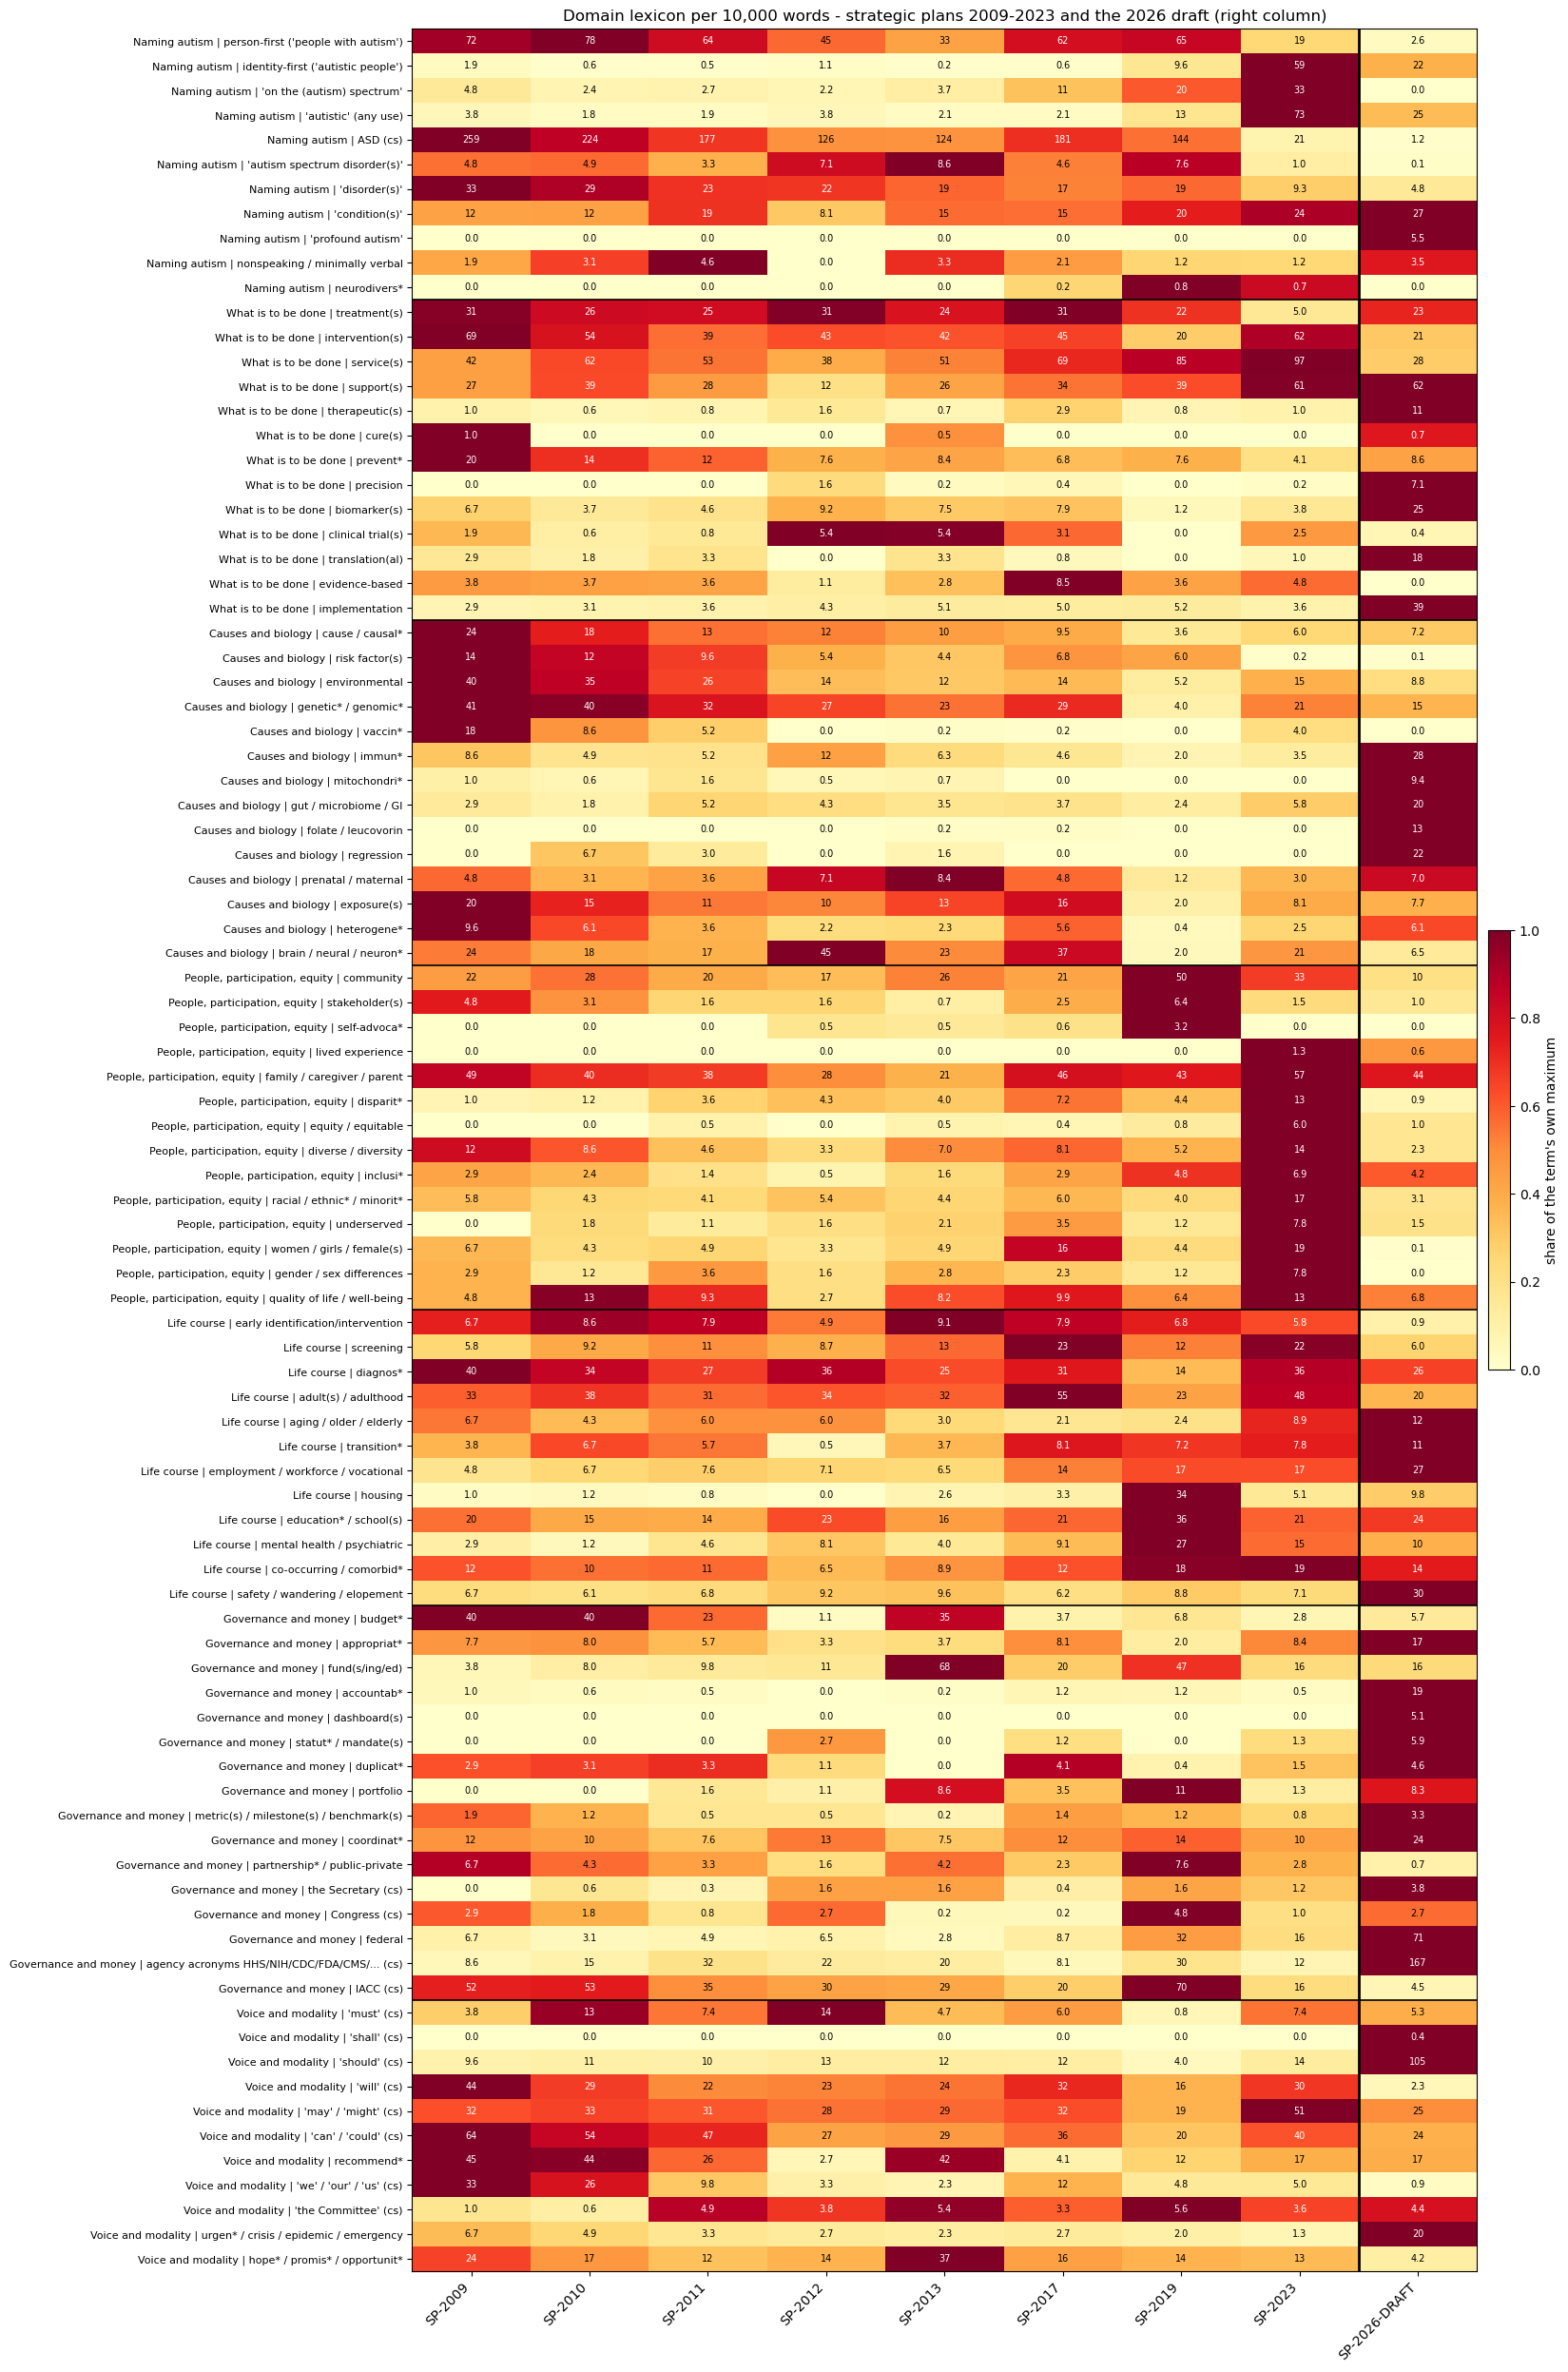

In [12]:
def lexicon_heatmap(table: pd.DataFrame, title: str, fname: str) -> None:
    """Row-normalised heatmap (each term scaled to its own maximum) with the per-10k values annotated."""
    values = table.to_numpy(dtype=float)
    scaled = values / np.where(np.nanmax(values, axis=1, keepdims=True) > 0, np.nanmax(values, axis=1, keepdims=True), 1)
    fig, ax = plt.subplots(figsize=(1.1 * table.shape[1] + 5, 0.32 * table.shape[0] + 1.5))
    im = ax.imshow(scaled, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
    ax.set_xticks(range(table.shape[1]))
    ax.set_xticklabels(table.columns, rotation=45, ha="right")
    ax.set_yticks(range(table.shape[0]))
    ax.set_yticklabels([f"{g} | {t}" for g, t in table.index], fontsize=8)
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            v = values[i, j]
            ax.text(j, i, f"{v:.0f}" if v >= 10 else f"{v:.1f}", ha="center", va="center", fontsize=7, color="black" if scaled[i, j] < 0.6 else "white")
    groups = [g for g, _ in table.index]
    for i in range(1, len(groups)):
        if groups[i] != groups[i - 1]:
            ax.axhline(i - 0.5, color="black", linewidth=1.2)
    ax.axvline(table.shape[1] - 1.5, color="black", linewidth=2)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label="share of the term's own maximum")
    savefig(fname)


lexicon_heatmap(LEXICON_PER10K[sp_ids], "Domain lexicon per 10,000 words - strategic plans 2009-2023 and the 2026 draft (right column)", "04_lexicon_strategic_plans")

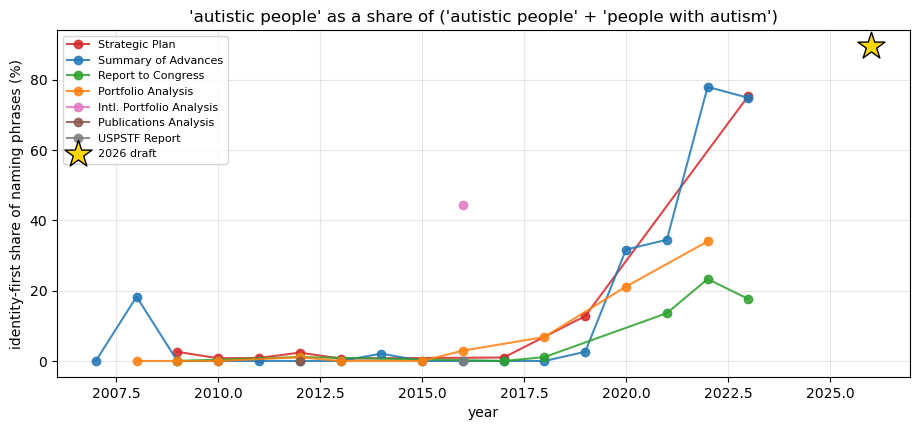

,series,year,is_draft,person_first_per10k,identity_first_per10k,identity_first_share
doc_id,,,,,,
SP-2009,strategic-plan,2009,False,71.956,1.919,0.026
SP-2010,strategic-plan,2010,False,77.690,0.612,0.008
SP-2011,strategic-plan,2011,False,63.633,0.546,0.009
SP-2012,strategic-plan,2012,False,44.524,1.086,0.024
SP-2013,strategic-plan,2013,False,33.359,0.233,0.007
SP-2017,strategic-plan,2017,False,62.478,0.621,0.010
SP-2019,strategic-plan,2019,False,65.318,9.559,0.128
SP-2023,strategic-plan,2023,False,19.175,58.684,0.754
SP-2026-DRAFT,strategic-plan,2026,True,2.568,22.008,0.896


In [13]:
# Identity-first share of the two naming conventions, all documents in the analysis set, by year.
pf = LEXICON_PER10K.loc[("Naming autism", "person-first ('people with autism')")]
idf = LEXICON_PER10K.loc[("Naming autism", "identity-first ('autistic people')")]
naming = pd.DataFrame({"person_first_per10k": pf, "identity_first_per10k": idf})
naming["identity_first_share"] = naming["identity_first_per10k"] / (naming["person_first_per10k"] + naming["identity_first_per10k"]).replace(0, np.nan)
naming = ANALYSIS[["doc_id", "series", "year", "is_draft"]].merge(naming, left_on="doc_id", right_index=True)

fig, ax = plt.subplots(figsize=(11, 4.5))
for series in order:
    sub = naming[(naming["series"] == series) & (~naming["is_draft"])].sort_values("year")
    if sub.empty:
        continue
    ax.plot(sub["year"], 100 * sub["identity_first_share"], marker="o", color=SERIES_COLOR[series], label=SERIES_LABEL[series], alpha=0.85)
d = naming[naming["is_draft"]].iloc[0]
ax.scatter([d["year"]], [100 * d["identity_first_share"]], marker="*", s=420, color="gold", edgecolor="black", zorder=5, label="2026 draft")
ax.set_ylabel("identity-first share of naming phrases (%)")
ax.set_xlabel("year")
ax.set_title("'autistic people' as a share of ('autistic people' + 'people with autism')")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
savefig("04_identity_first_share")
display(naming[naming["series"] == CFG.focus_series].set_index("doc_id").round(3))

## 5. Where the draft sits: z-scores against the earlier strategic plans and the whole record

For each style feature, the draft's value is expressed in standard deviations from (a) the eight earlier strategic
plans and (b) every document in the analysis set. |z| > 2 marks a feature on which the draft is unlike anything
the IACC has published in that comparison group.

,draft,prior SP mean,prior SP sd,prior SP min,prior SP max,z vs prior SP,all prior mean,all prior sd,z vs all prior,flag
should_per_1k,10.53,1.07,0.30,0.40,1.36,31.12,0.57,0.52,19.01,unlike any prior plan
deontic_index,0.66,0.21,0.05,0.12,0.29,8.95,0.14,0.07,6.98,unlike any prior plan
polysyllable_pct,35.43,24.02,1.48,22.17,26.43,7.72,22.97,1.74,7.14,unlike any prior plan
syllables_per_word,2.21,1.86,0.05,1.80,1.95,6.83,1.85,0.05,6.56,unlike any prior plan
letters_per_word,6.62,5.64,0.17,5.40,5.90,5.87,5.64,0.16,6.05,unlike any prior plan
mattr,0.55,0.49,0.01,0.48,0.50,5.82,0.46,0.04,2.45,unlike any prior plan
nominalisation_pct,11.77,7.55,0.77,6.86,9.06,5.46,7.98,1.25,3.03,unlike any prior plan
long_words_pct,49.41,37.85,2.15,34.68,40.61,5.37,38.46,2.76,3.96,unlike any prior plan
coleman_liau,21.59,15.91,1.13,14.63,17.84,5.04,15.57,1.09,5.53,unlike any prior plan
flesch_reading_ease,0.57,27.92,8.21,13.31,36.70,-3.33,32.65,7.15,-4.49,unlike any prior plan


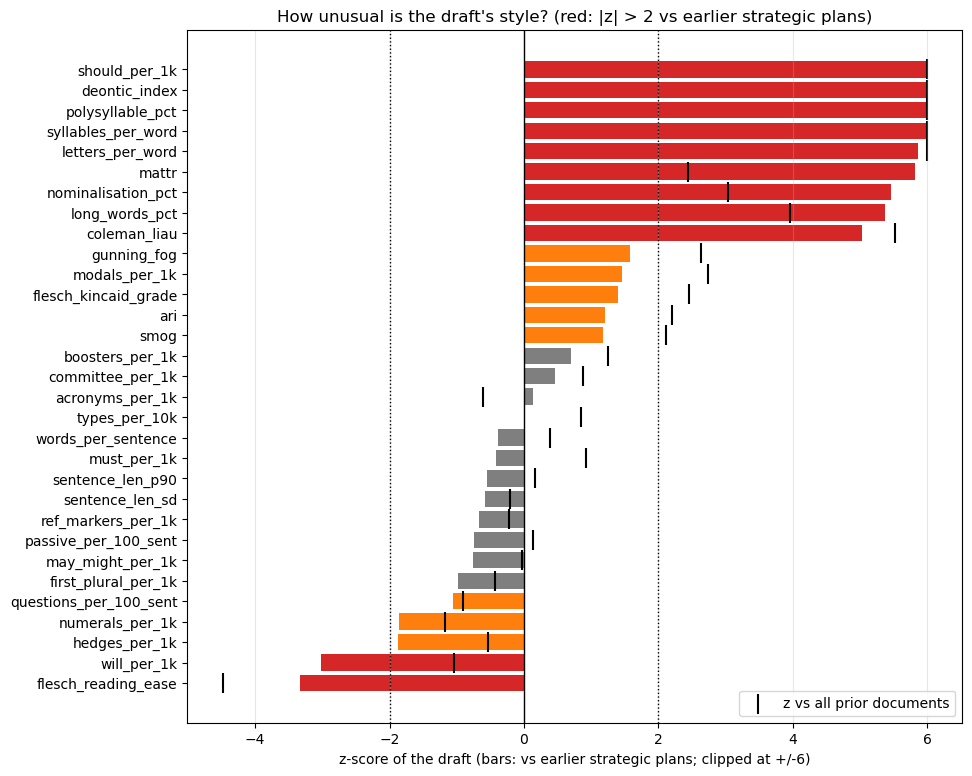

In [14]:
def zscore_table(features: pd.DataFrame, target_id: str, group_ids: Sequence[str], label: str) -> pd.DataFrame:
    grp = features[features["doc_id"].isin(group_ids)][STYLE_COLUMNS]
    target = features.loc[features["doc_id"] == target_id, STYLE_COLUMNS].iloc[0]
    mean, sd = grp.mean(), grp.std(ddof=1)
    z = (target - mean) / sd.replace(0, np.nan)
    return pd.DataFrame({"draft": target, f"{label} mean": mean, f"{label} sd": sd, f"{label} min": grp.min(), f"{label} max": grp.max(), f"z vs {label}": z})


# Size is not style: word and sentence counts stay in FEATURES but are not z-scored.
STYLE_COLUMNS = [c for c in FEATURE_COLUMNS if c not in ("n_words", "n_sentences")]
Z_SP = zscore_table(FEATURES, CFG.draft_id, PRIOR_SP["doc_id"], "prior SP")
Z_ALL = zscore_table(FEATURES, CFG.draft_id, PRIOR["doc_id"], "all prior")
ZTABLE = Z_SP.join(Z_ALL[["all prior mean", "all prior sd", "z vs all prior"]])
ZTABLE["group"] = [next(g for g, cols in FEATURE_GROUPS.items() if c in cols) for c in ZTABLE.index]
ZTABLE["flag"] = np.where(ZTABLE["z vs prior SP"].abs() > 2, "unlike any prior plan", np.where(ZTABLE["z vs prior SP"].abs() > 1, "notable", ""))
display(ZTABLE.drop(columns=["group"]).round(2).sort_values("z vs prior SP", key=lambda s: s.abs(), ascending=False))

fig, ax = plt.subplots(figsize=(10, 9))
z = ZTABLE.sort_values("z vs prior SP")
colors = ["#d62728" if abs(v) > 2 else ("#ff7f0e" if abs(v) > 1 else "#7f7f7f") for v in z["z vs prior SP"]]
ax.barh(z.index, z["z vs prior SP"].clip(-6, 6), color=colors)
ax.scatter(z["z vs all prior"].clip(-6, 6), z.index, marker="|", s=200, color="black", label="z vs all prior documents")
for x in (-2, 2):
    ax.axvline(x, color="black", linestyle=":", linewidth=1)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("z-score of the draft (bars: vs earlier strategic plans; clipped at +/-6)")
ax.set_title("How unusual is the draft's style? (red: |z| > 2 vs earlier strategic plans)")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
savefig("05_draft_style_zscores")

## 6. Keyness: what the draft says more, and what it stopped saying

Content words (stop words removed, plurals folded) are compared between the draft and a reference corpus with the
**weighted log-odds ratio with an informative Dirichlet prior** (Monroe, Colaresi & Quinn 2008): the prior is the
whole corpus's word distribution scaled to `keyness_alpha0` pseudo-counts, which stops rare words from dominating;
the z-score is the log-odds divided by its standard error. Rayson & Garside's log-likelihood (G²) is reported as a
second opinion. Three comparisons are run: the draft against all earlier strategic plans (unigrams and bigrams) and
the draft against the 2021-2023 plan alone. Two vocabulary lists follow: words the draft uses at least five times that
**never appeared** in any earlier IACC publication, and words that appeared in at least three earlier strategic plans
but are **absent** from the draft.

In [15]:
BOILERPLATE_STOP = {
    "et", "al", "doi", "pmid", "http", "https", "www", "org", "gov", "pdf", "fig", "figure", "table", "page", "pages", "pp", "vol", "issue",
    "ed", "eds", "www", "com", "html", "accessed", "retrieved", "available", "cited", "ibid",
}
CONTENT_STOP = set(ENGLISH_STOP_WORDS) | BOILERPLATE_STOP
TOKEN_RE = re.compile(r"[A-Za-z][A-Za-z'\-]*[A-Za-z]")
SURFACE: dict[str, Counter] = defaultdict(Counter)  # stem -> counts of the lower-cased forms it was seen as
TITLECASE: Counter = Counter()  # stem -> how often it was written Title-Case (Insel, Bureau, Indian): a name signal


def light_stem(word: str) -> str:
    """Fold trivial plurals so singular/plural forms count as one term."""
    if len(word) <= 4:
        return word
    if word.endswith("ies"):
        return word[:-3] + "y"
    if word.endswith("sses"):
        return word[:-2]
    if word.endswith("ses") and not word.endswith("ises"):
        return word[:-2]
    if word.endswith("s") and not word.endswith(("ss", "us", "is", "as")):
        return word[:-1]
    return word


def content_tokens(text: str) -> list[str]:
    out = []
    for raw in TOKEN_RE.findall(text):
        tok = raw.lower().strip("'-")
        if len(tok) < 3 or tok in CONTENT_STOP or not tok.replace("-", "").replace("'", "").isalpha():
            continue
        stem = light_stem(tok)
        SURFACE[stem][tok] += 1
        if raw[0].isupper() and raw[1:].islower():
            TITLECASE[stem] += 1
        out.append(stem)
    return out


def surface(stem: str) -> str:
    return SURFACE[stem].most_common(1)[0][0] if SURFACE.get(stem) else stem


def titlecase_share(stem: str) -> float:
    """Share of a term's occurrences written Title-Case; near 1 for names of people, agencies and places."""
    total = sum(SURFACE[stem].values()) if SURFACE.get(stem) else 0
    return TITLECASE[stem] / total if total else 0.0


def bigrams(tokens: Sequence[str]) -> list[str]:
    return [f"{a} {b}" for a, b in zip(tokens, tokens[1:])]


def surface_bigram(bg: str) -> str:
    return " ".join(surface(p) for p in bg.split(" "))


started = time.perf_counter()
TOKENS: dict[str, list[str]] = {r.doc_id: content_tokens(r.text) for r in ANALYSIS.itertuples()}
UNI: dict[str, Counter] = {k: Counter(v) for k, v in TOKENS.items()}
BI: dict[str, Counter] = {k: Counter(bigrams(v)) for k, v in TOKENS.items()}
print(f"tokenised {len(TOKENS)} documents ({sum(len(v) for v in TOKENS.values()):,} content tokens) in {time.perf_counter() - started:.1f}s")


def sum_counters(counters: Iterable[Counter]) -> Counter:
    total: Counter = Counter()
    for c in counters:
        total.update(c)
    return total


def weighted_log_odds(target: Counter, reference: Counter, prior: Counter, alpha0: float, min_count: int, render=surface) -> pd.DataFrame:
    """Monroe et al. (2008) weighted log-odds with informative Dirichlet prior, plus G² log-likelihood."""
    terms = sorted({t for t, c in target.items() if c >= min_count} | {t for t, c in reference.items() if c >= min_count})
    yt = np.array([target.get(t, 0) for t in terms], dtype=float)
    yr = np.array([reference.get(t, 0) for t in terms], dtype=float)
    n_t, n_r, n_p = sum(target.values()), sum(reference.values()), max(1, sum(prior.values()))
    a = np.maximum(alpha0 * np.array([prior.get(t, 0) for t in terms], dtype=float) / n_p, alpha0 / n_p)
    delta = np.log((yt + a) / (n_t + alpha0 - yt - a)) - np.log((yr + a) / (n_r + alpha0 - yr - a))
    z = delta / np.sqrt(1 / (yt + a) + 1 / (yr + a))
    et = n_t * (yt + yr) / (n_t + n_r)
    er = n_r * (yt + yr) / (n_t + n_r)
    with np.errstate(divide="ignore", invalid="ignore"):
        g2 = 2 * (np.where(yt > 0, yt * np.log(yt / et), 0) + np.where(yr > 0, yr * np.log(yr / er), 0))
    return pd.DataFrame(
        {
            "term": [render(t) for t in terms],
            "target_count": yt.astype(int),
            "reference_count": yr.astype(int),
            "target_per10k": yt / n_t * 1e4,
            "reference_per10k": yr / n_r * 1e4,
            "log_odds": delta,
            "z": z,
            "g2": g2,
        }
    ).sort_values("z", ascending=False).reset_index(drop=True)


PRIOR_SP_UNI = sum_counters(UNI[d] for d in PRIOR_SP["doc_id"])
PRIOR_SP_BI = sum_counters(BI[d] for d in PRIOR_SP["doc_id"])
CORPUS_UNI = sum_counters(UNI.values())
CORPUS_BI = sum_counters(BI.values())
sp2023_id = PRIOR_SP.iloc[-1]["doc_id"]

KEY_UNI = weighted_log_odds(UNI[CFG.draft_id], PRIOR_SP_UNI, CORPUS_UNI, CFG.keyness_alpha0, CFG.keyness_min_count)
KEY_BI = weighted_log_odds(BI[CFG.draft_id], PRIOR_SP_BI, CORPUS_BI, CFG.keyness_alpha0, CFG.keyness_min_count, render=surface_bigram)
KEY_VS_2023 = weighted_log_odds(UNI[CFG.draft_id], UNI[sp2023_id], CORPUS_UNI, CFG.keyness_alpha0, CFG.keyness_min_count)


def show_keyness(table: pd.DataFrame, title: str, top: int) -> None:
    display(Markdown(f"**{title} - over-used in the draft (top {top})**"))
    display(table.head(top).round(2))
    display(Markdown(f"**{title} - under-used in the draft (top {top})**"))
    display(table.tail(top).iloc[::-1].round(2))


show_keyness(KEY_UNI, "Draft vs earlier strategic plans, words", CFG.keyness_top)

tokenised 46 documents (618,891 content tokens) in 0.5s


**Draft vs earlier strategic plans, words - over-used in the draft (top 30)**

,term,target_count,reference_count,target_per10k,reference_per10k,log_odds,z,g2
0,federal,580,264,105.17,17.88,1.76,23.87,629.26
1,agencies,401,173,72.71,11.72,1.81,20.05,451.50
2,sleep,289,112,52.40,7.59,1.92,17.32,348.71
3,implementation,272,109,49.32,7.38,1.89,16.71,321.41
4,cms,213,31,38.62,2.10,2.89,15.16,388.58
5,domain,203,35,36.81,2.37,2.72,14.97,352.12
6,evidence,259,152,46.96,10.30,1.51,14.80,229.40
7,clinical,342,282,62.01,19.10,1.17,14.59,210.39
8,pathways,197,69,35.72,4.67,2.02,14.50,252.31
9,evaluation,216,104,39.17,7.04,1.70,14.32,224.96


**Draft vs earlier strategic plans, words - under-used in the draft (top 30)**

,term,target_count,reference_count,target_per10k,reference_per10k,log_odds,z,g2
3578,asd,10,3351,1.81,226.97,-3.84,-20.20,2016.87
3577,research,282,2528,51.13,171.23,-1.18,-19.29,507.76
3576,services,212,1735,38.44,117.52,-1.09,-15.35,313.21
3575,studies,189,1614,34.27,109.32,-1.14,-15.13,306.72
3574,iacc,37,809,6.71,54.80,-2.00,-12.61,305.94
3573,children,56,830,10.15,56.22,-1.59,-12.35,255.05
3572,autism,588,2736,106.62,185.32,-0.55,-12.20,165.75
3571,interventions,169,1208,30.64,81.82,-0.96,-11.94,181.53
3570,question,58,742,10.52,50.26,-1.45,-11.35,205.96
3569,community,82,783,14.87,53.03,-1.25,-10.96,168.23


In [16]:
show_keyness(KEY_BI, "Draft vs earlier strategic plans, bigrams", CFG.keyness_top)

**Draft vs earlier strategic plans, bigrams - over-used in the draft (top 30)**

,term,target_count,reference_count,target_per10k,reference_per10k,log_odds,z,g2
0,life course,59,13,10.70,0.88,2.48,8.13,93.90
1,lead agencies,97,2,17.59,0.14,4.78,6.96,234.31
2,federal autism,39,9,7.07,0.61,2.43,6.61,60.95
3,national autism,29,10,5.26,0.68,2.03,5.57,37.47
4,medication effects,27,3,4.90,0.20,3.16,5.23,52.71
5,clinically meaningful,29,2,5.26,0.14,3.62,5.02,61.96
6,functional outcomes,24,9,4.35,0.61,1.95,5.01,29.54
7,standards care,22,6,3.99,0.41,2.26,4.94,32.00
8,data elements,27,2,4.90,0.14,3.55,4.91,57.03
9,sleep disruption,42,1,7.62,0.07,4.64,4.75,100.51


**Draft vs earlier strategic plans, bigrams - under-used in the draft (top 30)**

,term,target_count,reference_count,target_per10k,reference_per10k,log_odds,z,g2
4938,strategic plan,37,489,6.71,33.12,-1.53,-9.35,139.01
4937,autism spectrum,1,508,0.18,34.41,-3.79,-7.89,310.62
4936,services support,19,261,3.45,17.68,-1.59,-6.89,76.25
4935,iacc strategic,12,235,2.18,15.92,-1.87,-6.75,84.43
4934,individuals autism,14,202,2.54,13.68,-1.63,-6.10,61.00
4933,people asd,1,363,0.18,24.59,-4.15,-6.09,219.24
4932,asd research,0,278,0.00,18.83,-3.89,-5.70,176.47
4931,autism research,38,277,6.89,18.76,-0.95,-5.69,42.84
4930,environmental factors,9,156,1.63,10.57,-1.82,-5.47,52.61
4929,individuals asd,1,203,0.18,13.75,-3.69,-5.10,118.84


In [17]:
show_keyness(KEY_VS_2023, f"Draft vs {sp2023_id} alone, words", 20)

**Draft vs SP-2023 alone, words - over-used in the draft (top 20)**

,term,target_count,reference_count,target_per10k,reference_per10k,log_odds,z,g2
0,federal,580,92,105.17,26.23,1.37,12.45,208.13
1,agencies,401,38,72.71,10.84,1.85,11.29,207.97
2,clinical,342,41,62.01,11.69,1.64,10.15,153.46
3,sleep,289,26,52.40,7.41,1.94,9.62,154.11
4,implementation,272,22,49.32,6.27,2.03,9.38,152.94
5,measures,290,46,52.58,13.12,1.38,8.79,104.06
6,evidence,259,36,46.96,10.27,1.50,8.59,104.12
7,nih,227,12,41.16,3.42,2.36,8.56,150.94
8,safety,221,27,40.07,7.70,1.63,8.14,97.87
9,domain,203,14,36.81,3.99,2.20,8.10,122.46


**Draft vs SP-2023 alone, words - under-used in the draft (top 20)**

,term,target_count,reference_count,target_per10k,reference_per10k,log_odds,z,g2
2233,autism,588,1066,106.62,303.98,-1.04,-20.58,440.59
2232,services,212,584,38.44,166.53,-1.44,-18.30,389.68
2231,research,282,611,51.13,174.23,-1.20,-17.03,318.44
2230,individuals,222,495,40.25,141.15,-1.24,-15.52,266.65
2229,autistic,203,433,36.81,123.47,-1.20,-14.20,221.54
2228,interventions,169,376,30.64,107.22,-1.23,-13.48,202.04
2227,community,82,244,14.87,69.58,-1.51,-12.04,174.11
2226,needed,46,192,8.34,54.75,-1.85,-11.43,174.45
2225,studies,189,336,34.27,95.81,-1.01,-11.26,134.95
2224,spectrum,5,257,0.91,73.29,-3.84,-11.20,441.12


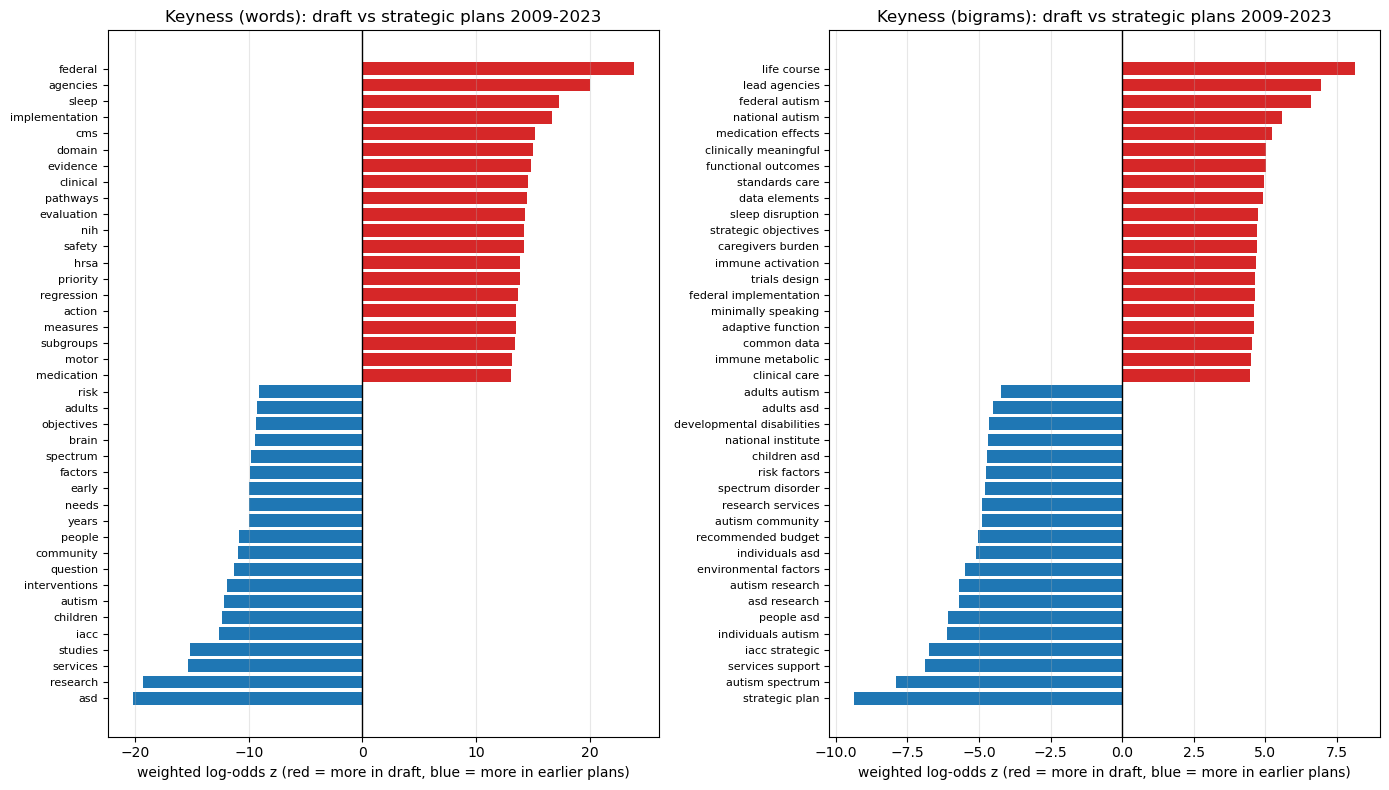

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
for ax, table, label in zip(axes, (KEY_UNI, KEY_BI), ("words", "bigrams")):
    top = pd.concat([table.head(20), table.tail(20)]).sort_values("z")
    ax.barh(top["term"], top["z"], color=np.where(top["z"] > 0, "#d62728", "#1f77b4"))
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"Keyness ({label}): draft vs strategic plans 2009-2023")
    ax.set_xlabel("weighted log-odds z (red = more in draft, blue = more in earlier plans)")
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
savefig("06_keyness_draft_vs_prior_plans")

In [19]:
# Vocabulary that is entirely new to the IACC record, and vocabulary the draft has dropped.
prior_ids = list(PRIOR["doc_id"])
prior_uni = sum_counters(UNI[d] for d in prior_ids)
n_draft_tokens = sum(UNI[CFG.draft_id].values())
NEW_WORDS = (
    pd.DataFrame(
        [{"term": surface(t), "draft_count": c, "draft_per10k": c / n_draft_tokens * 1e4, "titlecase_share": titlecase_share(t)} for t, c in UNI[CFG.draft_id].items() if c >= CFG.keyness_min_count and prior_uni.get(t, 0) == 0]
    )
    .sort_values("draft_count", ascending=False)
    .reset_index(drop=True)
)
NEW_WORDS["kind"] = np.where(NEW_WORDS["titlecase_share"] > CFG.proper_noun_share, "name", "word")

sp_doc_freq = Counter()
sp_mean_per10k: dict[str, float] = defaultdict(float)
for d in PRIOR_SP["doc_id"]:
    n = sum(UNI[d].values())
    for t, c in UNI[d].items():
        if c >= CFG.keyness_min_count:
            sp_doc_freq[t] += 1
        sp_mean_per10k[t] += c / n * 1e4 / len(PRIOR_SP)
DROPPED_WORDS = (
    pd.DataFrame(
        [{"term": surface(t), "prior_plans_using_it": k, "prior_SP_mean_per10k": sp_mean_per10k[t], "draft_count": UNI[CFG.draft_id].get(t, 0), "titlecase_share": titlecase_share(t)} for t, k in sp_doc_freq.items() if k >= 3 and UNI[CFG.draft_id].get(t, 0) == 0]
    )
    .sort_values(["prior_plans_using_it", "prior_SP_mean_per10k"], ascending=False)
    .reset_index(drop=True)
)
DROPPED_WORDS["kind"] = np.where(DROPPED_WORDS["titlecase_share"] > CFG.proper_noun_share, "name", "word")
display(Markdown(f"**{len(NEW_WORDS)} words used 5+ times in the draft that never appear in any earlier IACC publication** (top 60 by count; `kind` = name when mostly written Title-Case)"))
display(NEW_WORDS.head(60).round(2))
display(Markdown(f"**{(DROPPED_WORDS['kind'] == 'word').sum()} words used 5+ times in 3+ earlier strategic plans that are absent from the draft** (top 60; {(DROPPED_WORDS['kind'] == 'name').sum()} names of people/organisations are kept in the CSV but not shown)"))
display(DROPPED_WORDS[DROPPED_WORDS["kind"] == "word"].head(60).round(2))

**176 words used 5+ times in the draft that never appear in any earlier IACC publication** (top 60 by count; `kind` = name when mostly written Title-Case)

,term,draft_count,draft_per10k,titlecase_share,kind
0,dashboard,42,7.62,0.36,word
1,workplans,42,7.62,0.02,word
2,compact,39,7.07,0.51,word
3,comparative-effectiveness,38,6.89,0.13,word
4,napti,38,6.89,0.00,word
5,biomarker-defined,37,6.71,0.05,word
6,implementation-ready,34,6.17,0.44,word
7,praxis,32,5.80,0.25,word
8,tier,31,5.62,0.45,word
9,speech-motor,23,4.17,0.13,word


**54 words used 5+ times in 3+ earlier strategic plans that are absent from the draft** (top 60; 13 names of people/organisations are kept in the CSV but not shown)

,term,prior_plans_using_it,prior_SP_mean_per10k,draft_count,titlecase_share,kind
0,sharing,7,7.82,0,0.06,word
1,enhance,7,7.15,0,0.07,word
2,scientists,7,5.73,0,0.21,word
4,evidence-based,6,6.95,0,0.03,word
5,repository,6,6.89,0,0.18,word
6,mutations,6,6.63,0,0.04,word
7,infants,6,6.53,0,0.14,word
8,various,6,3.84,0,0.08,word
9,aspects,6,3.73,0,0.01,word
11,prevented,5,5.53,0,0.30,word


## 7. Similarity and stylometry

**Content similarity.** Each document becomes a TF-IDF vector over its content words and bigrams; cosine similarity
says how much two documents talk about the same things. The heatmap covers the strategic-plan series; the ranked table
and the 2-D map (metric MDS on cosine distance) cover every document in the analysis set.

**Style similarity.** Burrows' Delta uses only the `mfw_count` most frequent words of the corpus - overwhelmingly
function words (the, of, and, to, should ...) - whose rates reflect *how* a text is written rather than what it is about.
Each word's rate is z-scored across documents; Delta between two documents is the mean absolute difference of their
z-scores. The dendrogram clusters the record by style alone.

**Content similarity of every earlier document to the draft (TF-IDF cosine)**

,cosine_to_draft,series,year
SP-2023,0.288,strategic-plan,2023
SP-2017,0.263,strategic-plan,2017
RTC-2023,0.249,report-to-congress,2023
RTC-2022,0.241,report-to-congress,2022
RTC-2017,0.227,report-to-congress,2017
RTC-2021,0.219,report-to-congress,2021
RTC-2018,0.218,report-to-congress,2018
RTC-2012,0.212,report-to-congress,2012
SP-2012,0.211,strategic-plan,2012
SP-2013,0.210,strategic-plan,2013


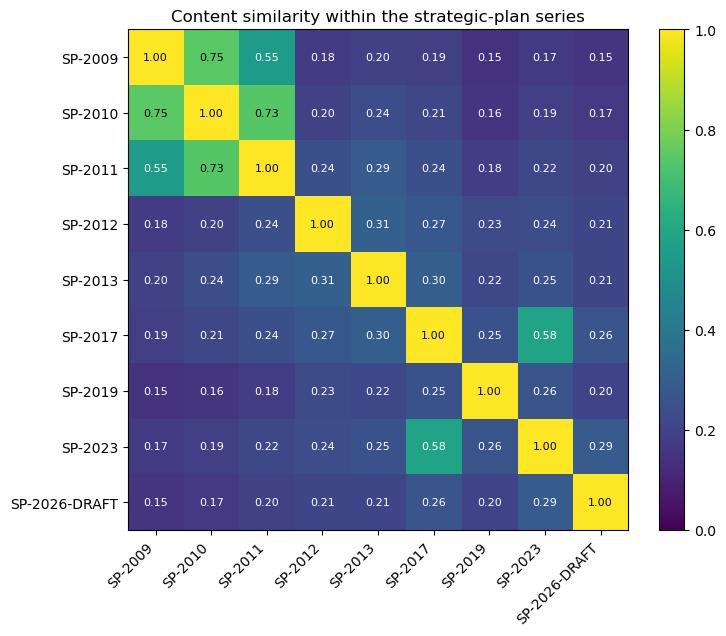

In [20]:
def tfidf_analyzer(text: str) -> list[str]:
    toks = content_tokens(text)
    return toks + bigrams(toks)


ids = list(ANALYSIS["doc_id"])
TFIDF = TfidfVectorizer(analyzer=tfidf_analyzer, min_df=2, sublinear_tf=True, norm="l2")
X_TFIDF = TFIDF.fit_transform([TEXT[d] for d in ids])
SIM = pd.DataFrame(cosine_similarity(X_TFIDF), index=ids, columns=ids)

meta = ANALYSIS.set_index("doc_id")
SIM_TO_DRAFT = pd.DataFrame({"cosine_to_draft": SIM[CFG.draft_id].drop(CFG.draft_id)})
SIM_TO_DRAFT["series"] = meta.loc[SIM_TO_DRAFT.index, "series"].values
SIM_TO_DRAFT["year"] = meta.loc[SIM_TO_DRAFT.index, "year"].values
SIM_TO_DRAFT = SIM_TO_DRAFT.sort_values("cosine_to_draft", ascending=False)
display(Markdown("**Content similarity of every earlier document to the draft (TF-IDF cosine)**"))
display(SIM_TO_DRAFT.round(3))

fig, ax = plt.subplots(figsize=(8, 6.5))
sub = SIM.loc[sp_ids, sp_ids]
im = ax.imshow(sub, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(sp_ids)))
ax.set_xticklabels(sp_ids, rotation=45, ha="right")
ax.set_yticks(range(len(sp_ids)))
ax.set_yticklabels(sp_ids)
for i in range(len(sp_ids)):
    for j in range(len(sp_ids)):
        ax.text(j, i, f"{sub.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8, color="white" if sub.iloc[i, j] < 0.6 else "black")
ax.set_title("Content similarity within the strategic-plan series")
fig.colorbar(im, ax=ax, fraction=0.046)
savefig("07_similarity_strategic_plans")

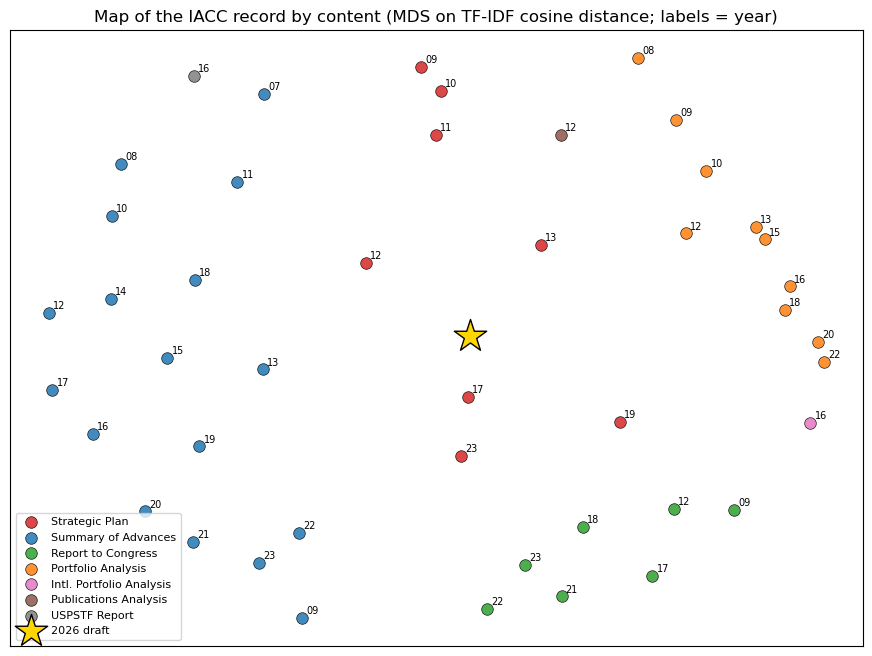

In [21]:
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=CFG.random_state, normalized_stress="auto")
coords = mds.fit_transform(1 - SIM.to_numpy())
fig, ax = plt.subplots(figsize=(11, 8))
for series in order:
    mask = (meta.loc[ids, "series"] == series).to_numpy() & (~meta.loc[ids, "is_draft"]).to_numpy()
    if mask.any():
        ax.scatter(coords[mask, 0], coords[mask, 1], color=SERIES_COLOR[series], label=SERIES_LABEL[series], s=70, alpha=0.85, edgecolor="black", linewidth=0.5)
for i, d in enumerate(ids):
    if d != CFG.draft_id:
        ax.annotate(str(int(meta.loc[d, "year"]))[2:], (coords[i, 0], coords[i, 1]), fontsize=7, xytext=(3, 3), textcoords="offset points")
di = ids.index(CFG.draft_id)
ax.scatter(coords[di, 0], coords[di, 1], marker="*", s=600, color="gold", edgecolor="black", zorder=5, label="2026 draft")
ax.set_title("Map of the IACC record by content (MDS on TF-IDF cosine distance; labels = year)")
ax.legend(fontsize=8)
ax.set_xticks([])
ax.set_yticks([])
savefig("07_content_map_mds")

most frequent words used for Delta: and, the, of, to, in, for, with, a, autism, asd, research, that, on, is, as, services, are, health, children, by, funding, question, this, or, be, projects, from, iacc, have, other, not, individuals, these, an, studies, at, was, interventions, their, s ...


**Stylistic distance of every earlier document to the draft (Burrows' Delta; lower = more alike)**

,burrows_delta_to_draft,series,year,content_cosine_to_draft
SP-2011,1.132,strategic-plan,2011,0.198
SP-2017,1.148,strategic-plan,2017,0.263
SP-2012,1.158,strategic-plan,2012,0.211
SP-2019,1.168,strategic-plan,2019,0.200
SOA-2023,1.199,summary-of-advances,2023,0.156
SOA-2016,1.201,summary-of-advances,2016,0.138
SOA-2021,1.212,summary-of-advances,2021,0.145
SP-2023,1.219,strategic-plan,2023,0.288
RTC-2022,1.227,report-to-congress,2022,0.241
SOA-2020,1.227,summary-of-advances,2020,0.143


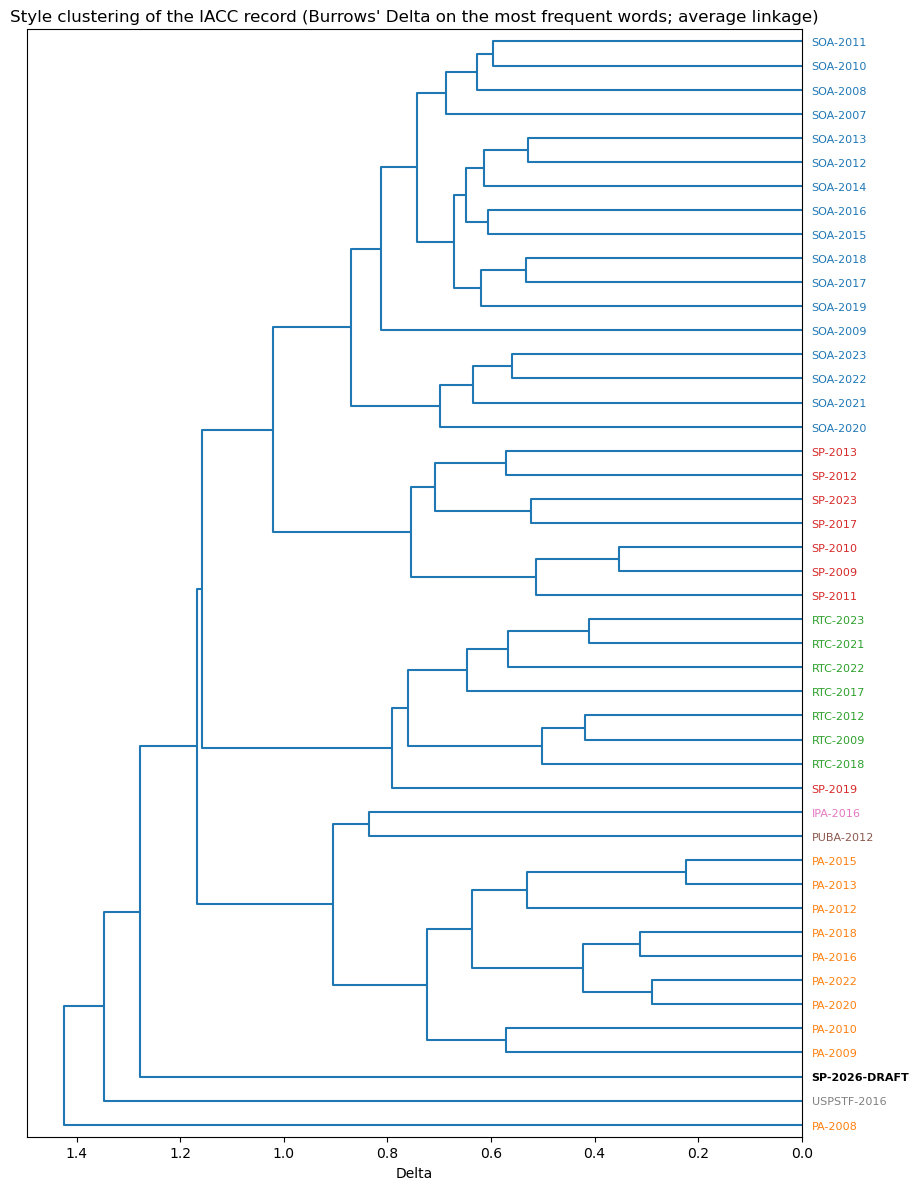

In [22]:
def burrows_delta(texts: dict[str, str], mfw: int) -> tuple[pd.DataFrame, list[str]]:
    """Burrows' Delta over the most frequent words; returns the distance matrix and the word list."""
    tokens = {d: [t.lower() for t in WORD_RE.findall(txt)] for d, txt in texts.items()}
    counts = {d: Counter(t) for d, t in tokens.items()}
    total = sum_counters(counts.values())
    words = [w for w, _ in total.most_common(mfw)]
    rates = pd.DataFrame({d: [counts[d][w] / max(1, len(tokens[d])) * 1000 for w in words] for d in texts}, index=words).T
    z = (rates - rates.mean()) / rates.std(ddof=0).replace(0, np.nan)
    z = z.fillna(0)
    arr = z.to_numpy()
    delta = np.abs(arr[:, None, :] - arr[None, :, :]).mean(axis=2)
    return pd.DataFrame(delta, index=z.index, columns=z.index), words


DELTA, MFW = burrows_delta({d: TEXT[d] for d in ids}, CFG.mfw_count)
print("most frequent words used for Delta:", ", ".join(MFW[:40]), "...")
DELTA_TO_DRAFT = pd.DataFrame({"burrows_delta_to_draft": DELTA[CFG.draft_id].drop(CFG.draft_id)})
DELTA_TO_DRAFT["series"] = meta.loc[DELTA_TO_DRAFT.index, "series"].values
DELTA_TO_DRAFT["year"] = meta.loc[DELTA_TO_DRAFT.index, "year"].values
DELTA_TO_DRAFT["content_cosine_to_draft"] = SIM_TO_DRAFT.loc[DELTA_TO_DRAFT.index, "cosine_to_draft"]
display(Markdown("**Stylistic distance of every earlier document to the draft (Burrows' Delta; lower = more alike)**"))
display(DELTA_TO_DRAFT.sort_values("burrows_delta_to_draft").round(3))

fig, ax = plt.subplots(figsize=(10, 0.28 * len(ids) + 1.5))
Z = linkage(squareform(DELTA.to_numpy(), checks=False), method="average")
dn = dendrogram(Z, labels=ids, orientation="left", ax=ax, leaf_font_size=8, color_threshold=0)
for lbl in ax.get_ymajorticklabels():
    d = lbl.get_text()
    lbl.set_color("black" if d == CFG.draft_id else SERIES_COLOR[meta.loc[d, "series"]])
    if d == CFG.draft_id:
        lbl.set_fontweight("bold")
ax.set_title("Style clustering of the IACC record (Burrows' Delta on the most frequent words; average linkage)")
ax.set_xlabel("Delta")
savefig("07_style_dendrogram")

## 8. Text reuse: how much of the draft is inherited text?

Every document is reduced to its sequence of 8-word shingles (lower-cased, punctuation removed). The share of the
draft's shingles that occur in an earlier document measures verbatim (or near-verbatim) inheritance from that
document; the share found in **any** earlier IACC publication is the draft's overall inherited fraction. For context,
the same inherited fraction is computed for every earlier strategic plan against everything the IACC had published
before it, so the draft's novelty can be judged against the series' own habit of carrying text forward. The longest
shared passages with the draft's largest source are printed at the end.

In [23]:
SHINGLE_TOKEN_RE = re.compile(r"[A-Za-z0-9]+")


def shingle_tokens(text: str) -> tuple[list[str], list[tuple[int, int]]]:
    toks, spans = [], []
    for m in SHINGLE_TOKEN_RE.finditer(text):
        toks.append(m.group(0).lower())
        spans.append(m.span())
    return toks, spans


def shingle_hashes(tokens: Sequence[str], n: int) -> list[int]:
    return [hash(" ".join(tokens[i : i + n])) for i in range(0, max(0, len(tokens) - n + 1))]


started = time.perf_counter()
SH_TOKENS: dict[str, tuple[list[str], list[tuple[int, int]]]] = {d: shingle_tokens(TEXT[d]) for d in ids}
SH_LIST: dict[str, list[int]] = {d: shingle_hashes(SH_TOKENS[d][0], CFG.shingle_n) for d in ids}
SH_SET: dict[str, set[int]] = {d: set(v) for d, v in SH_LIST.items()}
print(f"shingled {len(ids)} documents in {time.perf_counter() - started:.1f}s")


def share_in(source_list: list[int], target_set: set[int]) -> float:
    return sum(1 for h in source_list if h in target_set) / max(1, len(source_list))


draft_list = SH_LIST[CFG.draft_id]
prior_union: set[int] = set().union(*(SH_SET[d] for d in prior_ids))
REUSE = pd.DataFrame(
    [
        {
            "doc_id": d,
            "series": meta.loc[d, "series"],
            "year": meta.loc[d, "year"],
            "share_of_draft_found_in_doc": share_in(draft_list, SH_SET[d]),
            "share_of_doc_found_in_draft": share_in(SH_LIST[d], SH_SET[CFG.draft_id]),
            "shared_shingles": len(SH_SET[d] & SH_SET[CFG.draft_id]),
        }
        for d in prior_ids
    ]
).sort_values("share_of_draft_found_in_doc", ascending=False).reset_index(drop=True)
DRAFT_INHERITED = share_in(draft_list, prior_union)
print(f"{DRAFT_INHERITED:.1%} of the draft's {CFG.shingle_n}-word shingles occur somewhere in the earlier IACC record; {1 - DRAFT_INHERITED:.1%} are new text.")
display(REUSE.head(15).round(4))

shingled 46 documents in 0.4s
0.0% of the draft's 8-word shingles occur somewhere in the earlier IACC record; 100.0% are new text.


,doc_id,series,year,share_of_draft_found_in_doc,share_of_doc_found_in_draft,shared_shingles
0,SP-2023,strategic-plan,2023,0.0002,0.0004,14
1,RTC-2023,report-to-congress,2023,0.0001,0.0001,6
2,SP-2019,strategic-plan,2019,0.0001,0.0002,5
3,RTC-2017,report-to-congress,2017,0.0001,0.0002,5
4,RTC-2012,report-to-congress,2012,0.0000,0.0002,4
5,PA-2022,portfolio-analysis,2022,0.0000,0.0002,4
6,PA-2020,portfolio-analysis,2020,0.0000,0.0001,4
7,SP-2017,strategic-plan,2017,0.0000,0.0001,3
8,RTC-2018,report-to-congress,2018,0.0000,0.0001,3
9,RTC-2009,report-to-congress,2009,0.0000,0.0002,2


,doc_id,year,n_shingles,from_previous_plan,from_any_earlier_plan,from_any_earlier_publication,previous_plan_carried_forward,new_text_share
0,SP-2009,2009,10800,NaN,NaN,0.013,NaN,0.987
1,SP-2010,2010,17060,0.407,0.407,0.528,0.642,0.472
2,SP-2011,2011,38112,0.279,0.281,0.311,0.536,0.689
3,SP-2012,2012,19151,0.015,0.016,0.031,0.010,0.969
4,SP-2013,2013,45310,0.019,0.074,0.401,0.046,0.599
5,SP-2017,2017,50420,0.011,0.015,0.044,0.014,0.956
6,SP-2019,2019,25998,0.059,0.069,0.194,0.039,0.806
7,SP-2023,2023,62947,0.009,0.112,0.147,0.020,0.853
8,SP-2026-DRAFT,2026,85814,0.000,0.000,0.000,0.000,1.000


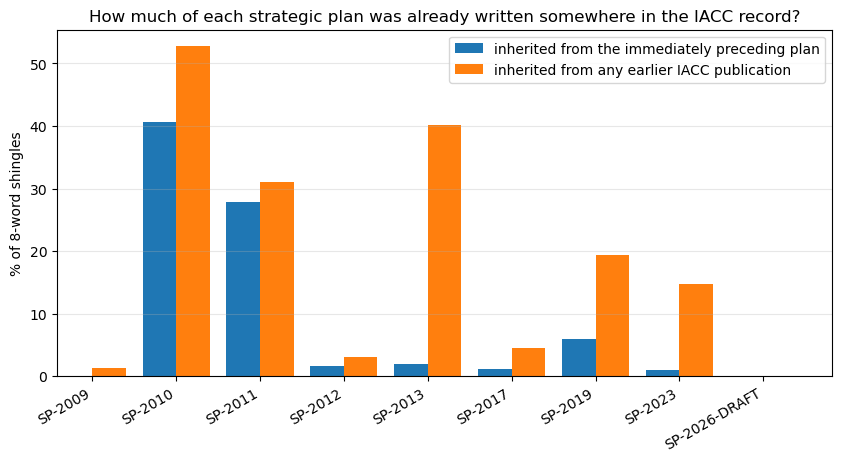

In [24]:
# The same inherited fraction for every earlier strategic plan, against everything published before it.
sp_chain = [*PRIOR_SP["doc_id"], CFG.draft_id]
rows = []
for i, d in enumerate(sp_chain):
    year = int(meta.loc[d, "year"])
    earlier_all = [e for e in ids if e != d and meta.loc[e, "year"] < year]
    earlier_sp = [e for e in sp_chain[:i]]
    prev = sp_chain[i - 1] if i else None
    union_all = set().union(*(SH_SET[e] for e in earlier_all)) if earlier_all else set()
    union_sp = set().union(*(SH_SET[e] for e in earlier_sp)) if earlier_sp else set()
    rows.append(
        {
            "doc_id": d,
            "year": year,
            "n_shingles": len(SH_LIST[d]),
            "from_previous_plan": share_in(SH_LIST[d], SH_SET[prev]) if prev else np.nan,
            "from_any_earlier_plan": share_in(SH_LIST[d], union_sp) if earlier_sp else np.nan,
            "from_any_earlier_publication": share_in(SH_LIST[d], union_all) if earlier_all else np.nan,
            "previous_plan_carried_forward": share_in(SH_LIST[prev], SH_SET[d]) if prev else np.nan,
        }
    )
CARRYOVER = pd.DataFrame(rows)
CARRYOVER["new_text_share"] = 1 - CARRYOVER["from_any_earlier_publication"]
display(CARRYOVER.round(3))

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(CARRYOVER))
ax.bar(x - 0.2, 100 * CARRYOVER["from_previous_plan"], width=0.4, label="inherited from the immediately preceding plan", color="#1f77b4")
ax.bar(x + 0.2, 100 * CARRYOVER["from_any_earlier_publication"], width=0.4, label="inherited from any earlier IACC publication", color="#ff7f0e")
ax.set_xticks(x)
ax.set_xticklabels(CARRYOVER["doc_id"], rotation=30, ha="right")
ax.set_ylabel(f"% of {CFG.shingle_n}-word shingles")
ax.set_title("How much of each strategic plan was already written somewhere in the IACC record?")
ax.legend()
ax.grid(axis="y", alpha=0.3)
savefig("08_inherited_text_by_plan")

In [25]:
def shared_passages(source_id: str, other_id: str, n: int, top: int = 10, min_run: int = 3) -> pd.DataFrame:
    """Longest runs of consecutive shingles of `source_id` that also occur in `other_id`."""
    toks, spans = SH_TOKENS[source_id]
    hits = [h in SH_SET[other_id] for h in SH_LIST[source_id]]
    runs, start = [], None
    for i, hit in enumerate([*hits, False]):
        if hit and start is None:
            start = i
        elif not hit and start is not None:
            if i - start >= min_run:
                runs.append((start, i - 1))
            start = None
    runs.sort(key=lambda r: r[1] - r[0], reverse=True)
    text = TEXT[source_id]
    return pd.DataFrame(
        [
            {"words": (e - s) + n, "position_in_draft": f"{s / max(1, len(toks)):.0%}", "passage": re.sub(r"\s+", " ", text[spans[s][0] : spans[e + n - 1][1]])}
            for s, e in runs[:top]
        ]
    )


top_source = REUSE.iloc[0]["doc_id"]
LONGEST_SHARED = shared_passages(CFG.draft_id, top_source, CFG.shingle_n, min_run=1)
display(Markdown(f"**Longest passages the draft shares with its largest single source, {top_source}**"))
with pd.option_context("display.max_colwidth", 400):
    display(LONGEST_SHARED)

**Longest passages the draft shares with its largest single source, SP-2023**

,words,position_in_draft,passage
0,16,5%,"statement: The purpose of the IACC Strategic Plan for Autism Research, Services, and Policy is to"
1,8,2%,advises the Secretary of Health and Human Services
2,8,6%,to the Secretary of Health and Human Services
3,8,9%,the needs of autistic individuals and their families
4,8,70%,under the Individuals with Disabilities Education Act (IDEA
5,8,80%,President's Committee for People with Intellectual Disabilities
6,8,90%,advises the Secretary of Health and Human Services


## 9. Over the years

Style features and lexicon items are plotted by year for each series, with the draft placed at 2026. Then every content
word that appears in at least `trend_min_docs` earlier documents is tested for a monotonic trend across the record
(Spearman correlation between publication year and rate per 10,000 words). The strongest risers and fallers are listed
with the draft's own rate and a verdict on whether the draft **continues** or **reverses** the trend, judged against the
mean of documents from 2018 onwards. Finally, the drift of the strategic-plan series itself: each plan's content
similarity to its predecessor and to the draft.

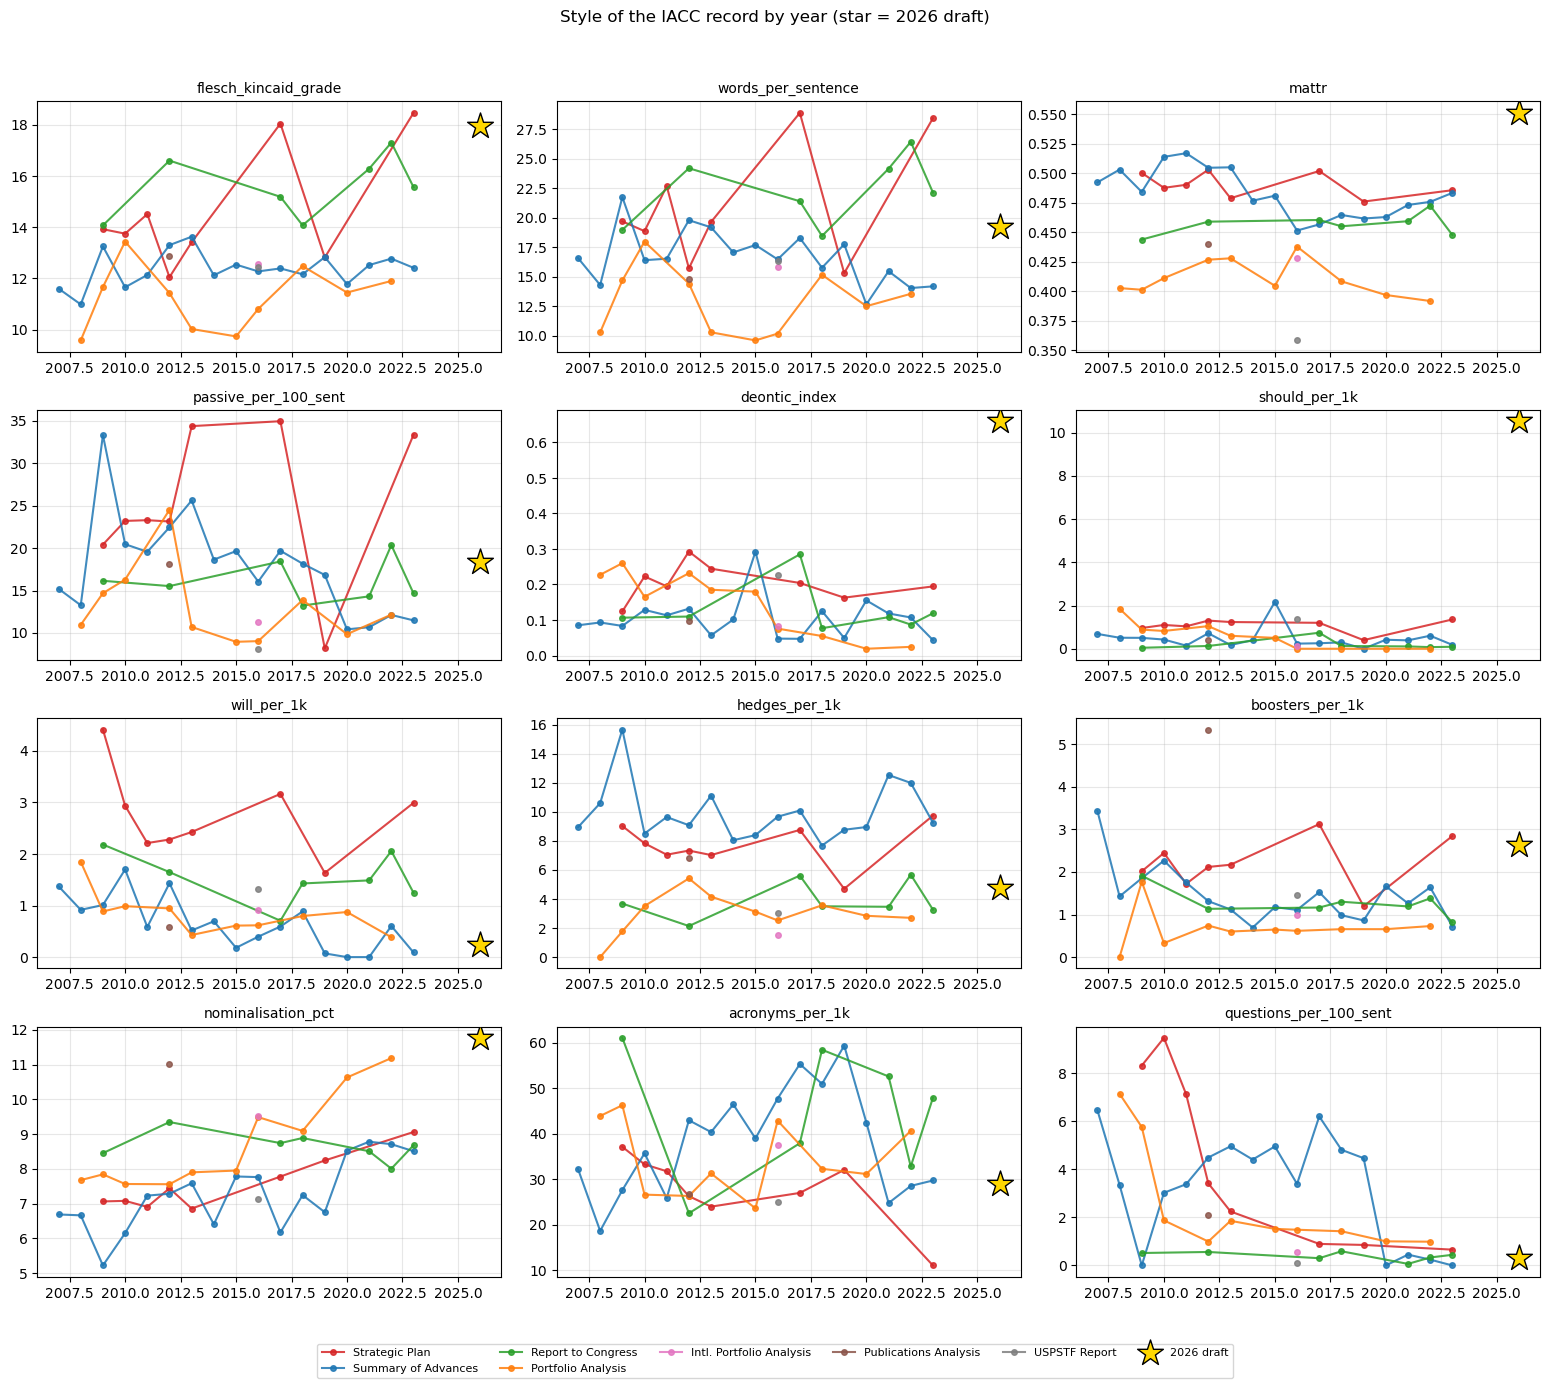

In [26]:
def plot_trends(frame: pd.DataFrame, columns: Sequence[str], titles: dict[str, str] | None, suptitle: str, fname: str, ncols: int = 3) -> None:
    n = len(columns)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.4 * nrows), squeeze=False)
    for ax, col in zip(axes.ravel(), columns):
        for series in order:
            sub = frame[(frame["series"] == series) & (~frame["is_draft"])].sort_values("year")
            if sub.empty or sub[col].isna().all():
                continue
            ax.plot(sub["year"], sub[col], marker="o", markersize=4, color=SERIES_COLOR[series], alpha=0.85, label=SERIES_LABEL[series])
        d = frame[frame["is_draft"]]
        if not d.empty:
            ax.scatter(d["year"], d[col], marker="*", s=380, color="gold", edgecolor="black", zorder=5, label="2026 draft")
        ax.set_title((titles or {}).get(col, col), fontsize=10)
        ax.grid(alpha=0.3)
    for ax in axes.ravel()[n:]:
        ax.axis("off")
    handles, labels = axes.ravel()[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=min(6, len(labels)), fontsize=8, bbox_to_anchor=(0.5, -0.01))
    fig.suptitle(suptitle, y=1.0)
    plt.tight_layout(rect=(0, 0.04, 1, 0.98))
    savefig(fname)


STYLE_TREND_COLS = ["flesch_kincaid_grade", "words_per_sentence", "mattr", "passive_per_100_sent", "deontic_index", "should_per_1k", "will_per_1k", "hedges_per_1k", "boosters_per_1k", "nominalisation_pct", "acronyms_per_1k", "questions_per_100_sent"]
plot_trends(FEATURES, STYLE_TREND_COLS, None, "Style of the IACC record by year (star = 2026 draft)", "09_style_trends")

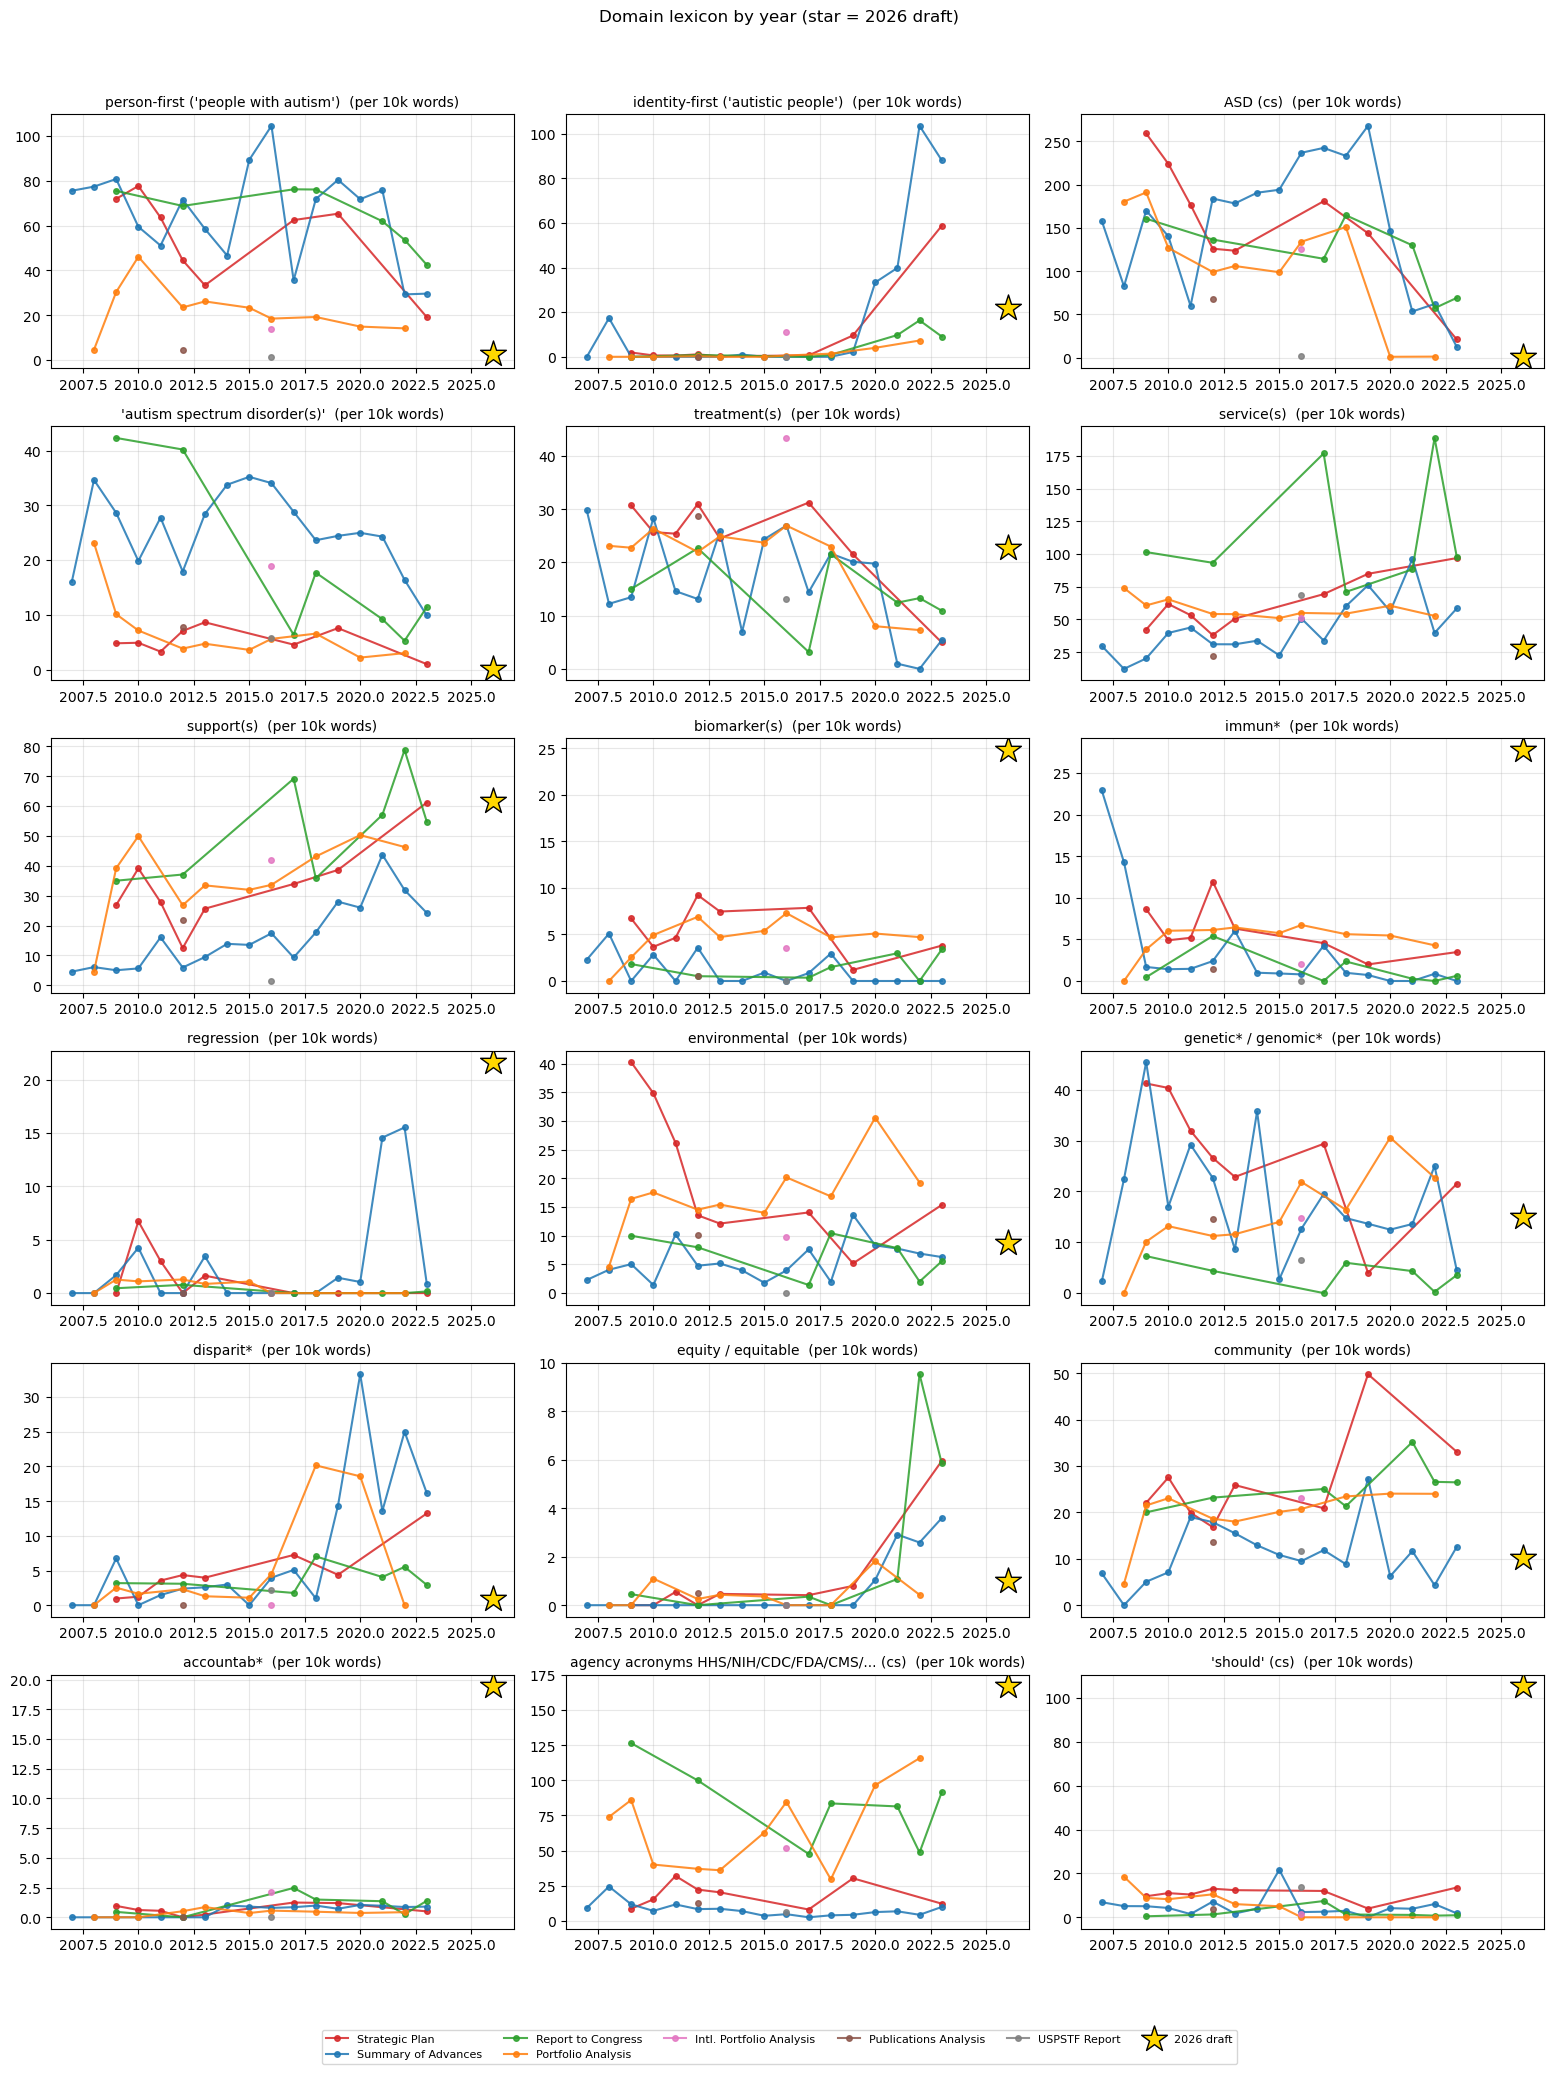

In [27]:
LEX_TREND = LEXICON_PER10K.T.copy()
LEX_TREND.columns = [f"{g} | {t}" for g, t in LEX_TREND.columns]
LEX_TREND = ANALYSIS[["doc_id", "series", "year", "is_draft"]].merge(LEX_TREND, left_on="doc_id", right_index=True)
LEX_TREND_COLS = [
    "Naming autism | person-first ('people with autism')", "Naming autism | identity-first ('autistic people')", "Naming autism | ASD (cs)",
    "Naming autism | 'autism spectrum disorder(s)'", "What is to be done | treatment(s)", "What is to be done | service(s)",
    "What is to be done | support(s)", "What is to be done | biomarker(s)", "Causes and biology | immun*",
    "Causes and biology | regression", "Causes and biology | environmental", "Causes and biology | genetic* / genomic*",
    "People, participation, equity | disparit*", "People, participation, equity | equity / equitable", "People, participation, equity | community",
    "Governance and money | accountab*", "Governance and money | agency acronyms HHS/NIH/CDC/FDA/CMS/... (cs)", "Voice and modality | 'should' (cs)",
]
plot_trends(LEX_TREND, LEX_TREND_COLS, {c: c.split(" | ")[1] + "  (per 10k words)" for c in LEX_TREND_COLS}, "Domain lexicon by year (star = 2026 draft)", "09_lexicon_trends")

In [28]:
def term_trends(counters: dict[str, Counter], docs: pd.DataFrame, draft_counter: Counter, cfg: Config, late_from: int = 2018) -> pd.DataFrame:
    """Spearman correlation of each term's rate with year across `docs`, plus the draft's rate and a continue/reverse verdict.

    Terms must occur in `trend_min_docs` documents, average `trend_min_rate` per 10k words, and not be names
    (Title-Case share above `proper_noun_share`): member rosters and agency lists would otherwise dominate.
    """
    doc_ids = list(docs["doc_id"])
    years = docs["year"].to_numpy(dtype=float)
    totals = {d: max(1, sum(counters[d].values())) for d in doc_ids}
    df_count = Counter()
    for d in doc_ids:
        df_count.update(counters[d].keys())
    terms = [t for t, k in df_count.items() if k >= cfg.trend_min_docs and titlecase_share(t) <= cfg.proper_noun_share]
    M = np.array([[counters[d].get(t, 0) / totals[d] * 1e4 for t in terms] for d in doc_ids])
    keep = M.mean(axis=0) >= cfg.trend_min_rate
    terms = [t for t, k in zip(terms, keep) if k]
    M = M[:, keep]
    ry = rankdata(years)
    R = np.apply_along_axis(rankdata, 0, M)
    ry_c = ry - ry.mean()
    R_c = R - R.mean(axis=0)
    rho = (R_c * ry_c[:, None]).sum(axis=0) / np.sqrt((R_c**2).sum(axis=0) * (ry_c**2).sum())
    early = M[years < 2013].mean(axis=0)
    late = M[years >= late_from].mean(axis=0)
    n_draft = max(1, sum(draft_counter.values()))
    draft = np.array([draft_counter.get(t, 0) / n_draft * 1e4 for t in terms])
    out = pd.DataFrame({"term": [surface(t) for t in terms], "spearman_rho": rho, "mean_per10k_before_2013": early, f"mean_per10k_{late_from}_on": late, "draft_per10k": draft, "n_docs": [df_count[t] for t in terms]})
    rising = out["spearman_rho"] > 0
    out["draft_verdict"] = np.where((rising & (out["draft_per10k"] >= out[f"mean_per10k_{late_from}_on"])) | (~rising & (out["draft_per10k"] <= out[f"mean_per10k_{late_from}_on"])), "continues trend", "reverses trend")
    return out.sort_values("spearman_rho", ascending=False).reset_index(drop=True)


TRENDS = term_trends(UNI, PRIOR, UNI[CFG.draft_id], CFG)
display(Markdown(f"**Terms rising across the IACC record 2007-2023 (top {CFG.trend_top} by Spearman rho, {len(PRIOR)} documents, {len(TRENDS)} terms tested)**"))
display(TRENDS.head(CFG.trend_top).round(2))
display(Markdown(f"**Terms falling across the IACC record (top {CFG.trend_top})**"))
display(TRENDS.tail(CFG.trend_top).iloc[::-1].round(2))
verdicts = TRENDS[TRENDS["spearman_rho"].abs() >= 0.5]["draft_verdict"].value_counts()
print(f"\nAmong the {int(verdicts.sum())} terms with |rho| >= 0.5, the draft continues the trend for {verdicts.get('continues trend', 0)} and reverses it for {verdicts.get('reverses trend', 0)}.")

**Terms rising across the IACC record 2007-2023 (top 25 by Spearman rho, 45 documents, 1906 terms tested)**

,term,spearman_rho,mean_per10k_before_2013,mean_per10k_2018_on,draft_per10k,n_docs,draft_verdict
0,college,0.75,0.78,3.45,0.54,34,reverses trend
1,veterans,0.72,0.02,2.40,0.00,14,reverses trend
2,accessibility,0.71,0.14,2.17,1.81,18,reverses trend
3,suicide,0.70,0.17,6.62,2.18,21,reverses trend
4,prefer,0.69,0.11,1.81,0.00,17,reverses trend
5,equity,0.67,0.03,2.45,0.36,13,reverses trend
6,arts,0.66,0.13,2.39,0.00,29,reverses trend
7,care,0.66,12.25,43.31,54.58,43,continues trend
8,ensuring,0.65,0.21,2.37,0.73,26,reverses trend
9,regulation,0.63,0.25,2.91,5.26,24,continues trend


**Terms falling across the IACC record (top 25)**

,term,spearman_rho,mean_per10k_before_2013,mean_per10k_2018_on,draft_per10k,n_docs,draft_verdict
1905,happening,-0.75,6.40,0.04,0.00,24,continues trend
1904,hold,-0.74,7.20,0.18,1.63,30,reverses trend
1903,happen,-0.72,7.18,0.14,0.54,27,reverses trend
1902,concerned,-0.71,7.11,0.44,0.36,35,continues trend
1901,caused,-0.70,10.13,0.90,0.18,35,continues trend
1900,turn,-0.61,6.24,0.52,0.91,34,reverses trend
1899,abnormalities,-0.59,4.34,0.18,2.54,26,reverses trend
1898,clues,-0.56,2.02,0.04,0.00,16,continues trend
1897,prevented,-0.56,7.04,1.87,0.00,32,continues trend
1896,developing,-0.56,16.95,7.14,1.09,43,continues trend



Among the 80 terms with |rho| >= 0.5, the draft continues the trend for 25 and reverses it for 55.


,doc_id,year,content_cosine_to_previous_plan,content_cosine_to_draft,style_delta_to_previous_plan,style_delta_to_draft
0,SP-2009,2009,NaN,0.151,NaN,1.324
1,SP-2010,2010,0.746,0.165,0.353,1.338
2,SP-2011,2011,0.734,0.198,0.502,1.132
3,SP-2012,2012,0.243,0.211,0.573,1.158
4,SP-2013,2013,0.307,0.210,0.571,1.234
5,SP-2017,2017,0.302,0.263,0.567,1.148
6,SP-2019,2019,0.254,0.200,0.910,1.168
7,SP-2023,2023,0.259,0.288,0.903,1.219
8,SP-2026-DRAFT,2026,0.288,NaN,1.219,NaN


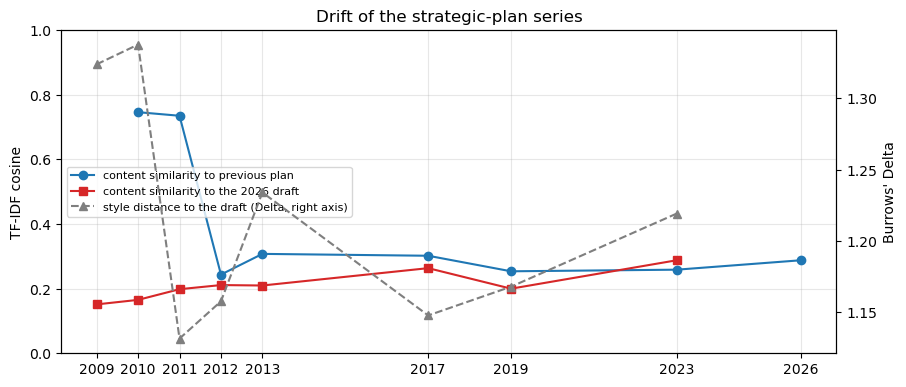

In [29]:
# Drift within the strategic-plan series: similarity to predecessor and to the draft.
DRIFT = pd.DataFrame(
    [
        {
            "doc_id": d,
            "year": int(meta.loc[d, "year"]),
            "content_cosine_to_previous_plan": SIM.loc[d, sp_chain[i - 1]] if i else np.nan,
            "content_cosine_to_draft": SIM.loc[d, CFG.draft_id] if d != CFG.draft_id else np.nan,
            "style_delta_to_previous_plan": DELTA.loc[d, sp_chain[i - 1]] if i else np.nan,
            "style_delta_to_draft": DELTA.loc[d, CFG.draft_id] if d != CFG.draft_id else np.nan,
        }
        for i, d in enumerate(sp_chain)
    ]
)
display(DRIFT.round(3))
fig, ax1 = plt.subplots(figsize=(10, 4.2))
ax1.plot(DRIFT["year"], DRIFT["content_cosine_to_previous_plan"], marker="o", color="#1f77b4", label="content similarity to previous plan")
ax1.plot(DRIFT["year"], DRIFT["content_cosine_to_draft"], marker="s", color="#d62728", label="content similarity to the 2026 draft")
ax1.set_ylabel("TF-IDF cosine")
ax1.set_ylim(0, 1)
ax2 = ax1.twinx()
ax2.plot(DRIFT["year"], DRIFT["style_delta_to_draft"], marker="^", linestyle="--", color="#7f7f7f", label="style distance to the draft (Delta, right axis)")
ax2.set_ylabel("Burrows' Delta")
ax1.set_xticks(DRIFT["year"])
ax1.grid(alpha=0.3)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=8, loc="center left")
ax1.set_title("Drift of the strategic-plan series")
savefig("09_strategic_plan_drift")

## 10. Inside the draft: section by section

The draft's PDF outline (depth `section_toc_level`) gives page ranges for its Parts and major sections. Each section is
profiled with the same measures, matched to its nearest earlier IACC document by content, scored for novelty (share of
its shingles absent from the whole earlier record), and given its most characteristic words relative to the earlier
strategic plans.

,section,pages,n_words,fk_grade,words_per_sentence,deontic_index,should_per_1k,identity_first_share,novel_text_share,nearest_prior_doc,nearest_cosine,characteristic_words
0,Executive Summary,17-25,4255,19.05,29.76,0.22,0.71,0.71,1.0,RTC-2017,0.17,"federal, domain, agencies, authority, agenda, action, plan, accountability"
1,Preface,26-30,2072,19.27,29.60,0.21,1.93,1.00,1.0,RTC-2017,0.13,"agencies, federal, authority, records, materials, implementation, plan, evidence"
2,Part I,31-33,1409,16.61,19.57,0.59,9.94,0.50,1.0,RTC-2017,0.13,"federal, discovery, implementation, action, enterprise, authority, translation, public"
3,"Rebalancing the Portfolio: Gaps, Duplication, and Budget Alignment",34-37,1928,17.40,21.91,0.79,10.37,0.00,1.0,SP-2017,0.13,"approximately, billion, nih, cost, annual, economic, roughly, validation"
4,Recommendation Structure and Plan Architecture,38-40,1026,16.92,19.00,0.70,11.70,1.00,1.0,RTC-2017,0.10,"federal, implementation, accountability, measurable, purpose, action, domain, authority"
5,Part II — Discovery Biology and the Case for Precision Translation,41-48,3254,17.89,23.08,0.34,3.38,0.80,1.0,SP-2017,0.15,"addm, feasibility, cohort, completed, federal, surveillance, analyses, rise"
6,Heterogeneity as the Organizing Principle,49-50,761,20.20,24.55,0.33,2.63,1.00,1.0,SP-2017,0.11,"completed, months, selected, sites, organizing, overlapping, expanded, linkage"
7,Contributing Factors and Causality,51-53,1278,22.19,29.05,0.12,0.78,0.67,1.0,SP-2017,0.12,"maternal, pathways, microbial, heritability, developmental, causation, metabolic, timing"
8,An Integrated Developmental Systems Framework,54-54,420,17.24,20.00,0.43,7.14,1.00,1.0,SP-2017,0.08,"physiological, resilience, biologically, systems, integrated, timing, vulnerability, interacting"
9,Implications for Federal Action,54-61,3289,20.60,24.73,0.63,11.25,0.83,1.0,SP-2017,0.16,"regression, metabolic, mitochondrial, biologically, timing, immune, stressors, developmental"


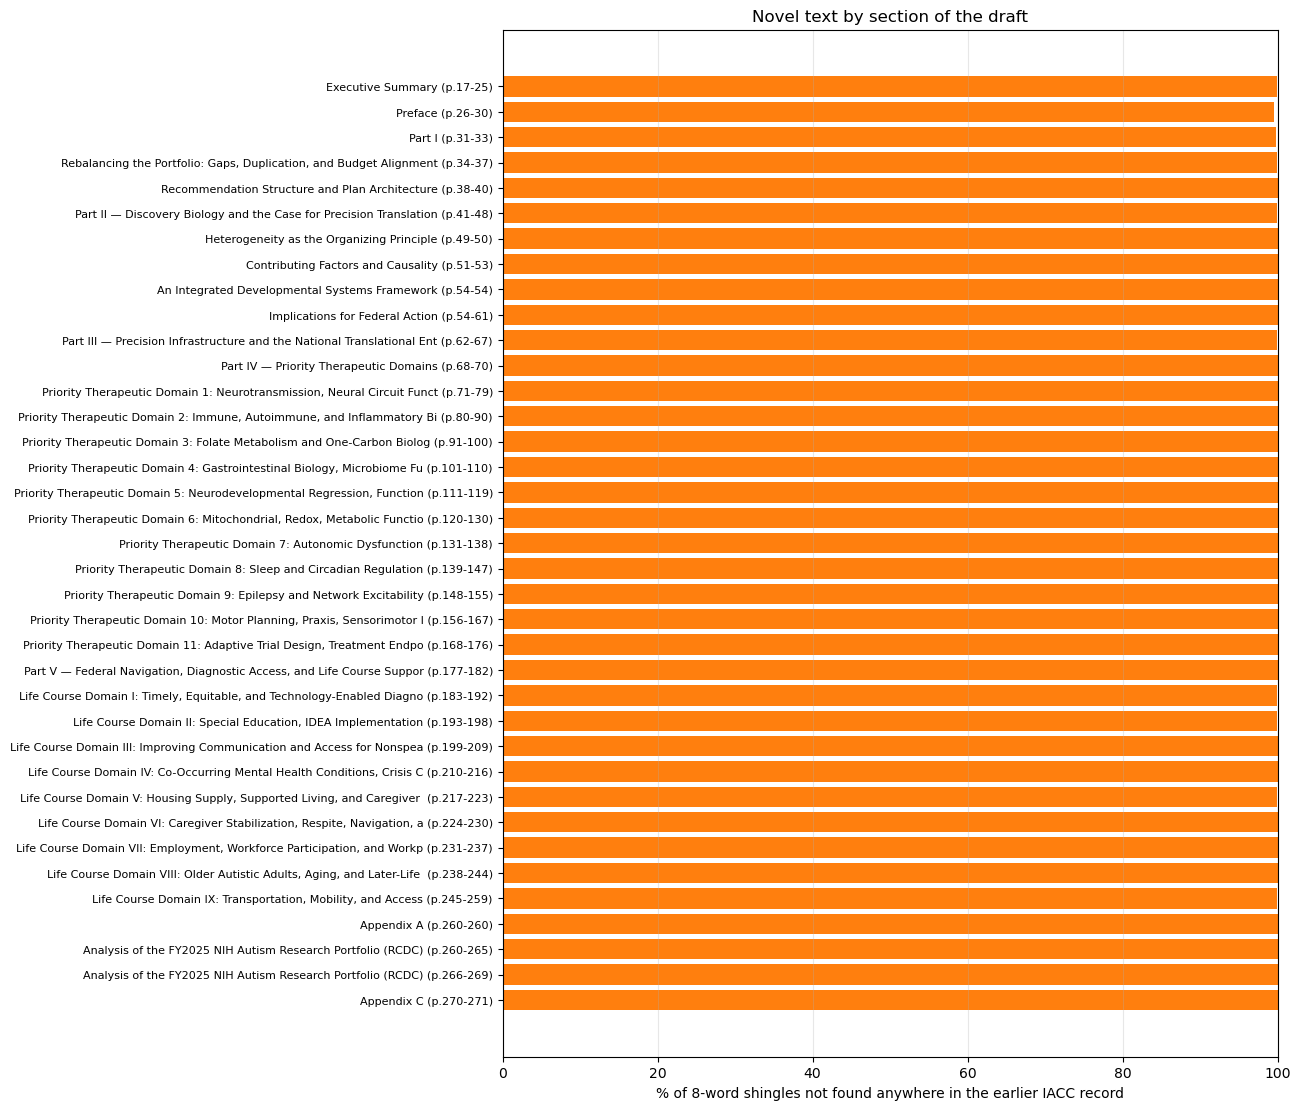

In [30]:
def outline_sections(doc_id: str, level: int, cfg: Config) -> pd.DataFrame:
    pages = PAGES_CLEAN[doc_id]
    entries = sorted([(pg, title.strip()) for lvl, title, pg in TOCS[doc_id] if lvl <= level and 1 <= pg <= len(pages)], key=lambda e: e[0])
    rows = []
    for i, (start, title) in enumerate(entries):
        end = entries[i + 1][0] - 1 if i + 1 < len(entries) else len(pages)
        if end < start:
            end = start
        text = pages_to_prose(pages[start - 1 : end])
        rows.append({"section": title, "page_start": start, "page_end": end, "n_words": len(WORD_RE.findall(text)), "text": text})
    return pd.DataFrame(rows)


SECTIONS = outline_sections(CFG.draft_id, CFG.section_toc_level, CFG)
if SECTIONS.empty or SECTIONS["n_words"].sum() < CFG.section_min_words:
    print("The draft's PDF has no usable outline; falling back to fixed 25-page blocks.")
    pages = PAGES_CLEAN[CFG.draft_id]
    SECTIONS = pd.DataFrame(
        [{"section": f"pages {s + 1}-{min(s + 25, len(pages))}", "page_start": s + 1, "page_end": min(s + 25, len(pages)), "text": pages_to_prose(pages[s : s + 25])} for s in range(0, len(pages), 25)]
    )
    SECTIONS["n_words"] = SECTIONS["text"].map(lambda t: len(WORD_RE.findall(t)))
SECTIONS = SECTIONS[SECTIONS["n_words"] >= CFG.section_min_words].reset_index(drop=True)

sec_rows = []
prior_matrix = X_TFIDF[[ids.index(d) for d in prior_ids]]
for r in SECTIONS.itertuples():
    prof = profile_text(r.text, CFG)
    toks, _ = shingle_tokens(r.text)
    sh = shingle_hashes(toks, CFG.shingle_n)
    novelty = 1 - share_in(sh, prior_union) if sh else np.nan
    sims = cosine_similarity(TFIDF.transform([r.text]), prior_matrix)[0]
    nearest = int(np.argmax(sims))
    lex = lexicon_counts(r.text)
    pf_c = lex[("Naming autism", "person-first ('people with autism')")]
    if_c = lex[("Naming autism", "identity-first ('autistic people')")]
    key = weighted_log_odds(Counter(content_tokens(r.text)), PRIOR_SP_UNI, CORPUS_UNI, CFG.keyness_alpha0, 3)
    sec_rows.append(
        {
            "section": r.section[:70],
            "pages": f"{r.page_start}-{r.page_end}",
            "n_words": prof.get("n_words", 0),
            "fk_grade": prof.get("flesch_kincaid_grade"),
            "words_per_sentence": prof.get("words_per_sentence"),
            "deontic_index": prof.get("deontic_index"),
            "should_per_1k": prof.get("should_per_1k"),
            "identity_first_share": if_c / (pf_c + if_c) if (pf_c + if_c) else np.nan,
            "novel_text_share": novelty,
            "nearest_prior_doc": prior_ids[nearest],
            "nearest_cosine": float(sims[nearest]),
            "characteristic_words": ", ".join(key.head(8)["term"]),
        }
    )
SECTION_TABLE = pd.DataFrame(sec_rows)
with pd.option_context("display.max_colwidth", 120):
    display(SECTION_TABLE.round(2))

fig, ax = plt.subplots(figsize=(10, 0.32 * len(SECTION_TABLE) + 1.5))
y = np.arange(len(SECTION_TABLE))[::-1]
ax.barh(y, 100 * SECTION_TABLE["novel_text_share"], color="#ff7f0e")
ax.set_yticks(y)
ax.set_yticklabels([f"{s} (p.{p})" for s, p in zip(SECTION_TABLE["section"], SECTION_TABLE["pages"])], fontsize=8)
ax.set_xlabel(f"% of {CFG.shingle_n}-word shingles not found anywhere in the earlier IACC record")
ax.set_xlim(0, 100)
ax.set_title("Novel text by section of the draft")
ax.grid(axis="x", alpha=0.3)
savefig("10_draft_section_novelty")

## 11. Export and report

Tables go to `output_dir` as CSV, figures were saved as they were drawn, and `report.md` states the headline numbers in
plain language.

In [31]:
def fmt_ratio(a: float, b: float) -> str:
    if not b or np.isnan(b):
        return "n/a"
    return f"{a / b:.1f}x"


def write_outputs(cfg: Config) -> Path:
    out = cfg.output_dir
    DOCS.drop(columns=["text"]).to_csv(out / "documents.csv", index=False)
    FEATURES.to_csv(out / "style_features.csv", index=False)
    LEXICON_PER10K.to_csv(out / "lexicon_per10k.csv")
    ZTABLE.to_csv(out / "draft_zscores.csv")
    KEY_UNI.to_csv(out / "keyness_words_vs_prior_plans.csv", index=False)
    KEY_BI.to_csv(out / "keyness_bigrams_vs_prior_plans.csv", index=False)
    KEY_VS_2023.to_csv(out / f"keyness_words_vs_{sp2023_id}.csv", index=False)
    NEW_WORDS.to_csv(out / "new_vocabulary.csv", index=False)
    DROPPED_WORDS.to_csv(out / "dropped_vocabulary.csv", index=False)
    SIM.to_csv(out / "content_similarity.csv")
    DELTA.to_csv(out / "style_delta.csv")
    REUSE.to_csv(out / "reuse_draft_vs_each_doc.csv", index=False)
    CARRYOVER.to_csv(out / "reuse_carryover_by_plan.csv", index=False)
    TRENDS.to_csv(out / "term_trends.csv", index=False)
    DRIFT.to_csv(out / "strategic_plan_drift.csv", index=False)
    SECTION_TABLE.to_csv(out / "draft_sections.csv", index=False)

    d = FEATURES[FEATURES["is_draft"]].iloc[0]
    sp = FEATURES[FEATURES["doc_id"].isin(PRIOR_SP["doc_id"])]
    lex_d = LEXICON_PER10K[cfg.draft_id]
    lex_sp_mean = LEXICON_PER10K[list(PRIOR_SP["doc_id"])].mean(axis=1)
    unusual = ZTABLE[ZTABLE["flag"] == "unlike any prior plan"].sort_values("z vs prior SP", key=lambda s: s.abs(), ascending=False)
    nearest_content = SIM_TO_DRAFT.index[0]
    nearest_style = DELTA_TO_DRAFT.sort_values("burrows_delta_to_draft").index[0]
    carry_prev = CARRYOVER.set_index("doc_id")
    lines = [
        f"# {cfg.draft_path.name} - linguistic comparison with the IACC publication record",
        "",
        f"Corpus: {len(ANALYSIS)} documents in the analysis set ({len(PRIOR_SP)} earlier strategic plans, {len(PRIOR) - len(PRIOR_SP)} other publications, 1 draft); "
        f"{(~DOCS['in_analysis']).sum()} inventoried documents excluded as too short or easy-read/at-a-glance editions.",
        "",
        "## Size and shape",
        f"- Draft: {int(d['n_words']):,} words on {int(DRAFT['n_pages_kept'])} pages of prose ({int(DRAFT['ref_pages_dropped'])} reference pages removed"
        + (f", trailing reference list from p.{int(DRAFT['ref_cut_page'])}" if pd.notna(DRAFT["ref_cut_page"]) else "") + "); "
        f"earlier plans averaged {sp['n_words'].mean():,.0f} words (max {sp['n_words'].max():,.0f}, {sp.loc[sp['n_words'].idxmax(), 'doc_id']}).",
        f"- Sentences: {d['words_per_sentence']:.1f} words per sentence vs {sp['words_per_sentence'].mean():.1f} in earlier plans; "
        f"Flesch-Kincaid grade {d['flesch_kincaid_grade']:.1f} vs {sp['flesch_kincaid_grade'].mean():.1f}; "
        f"Flesch Reading Ease {d['flesch_reading_ease']:.0f} vs {sp['flesch_reading_ease'].mean():.0f}.",
        f"- Lexical diversity (MATTR-{cfg.mattr_window}): {d['mattr']:.3f} vs {sp['mattr'].mean():.3f}.",
        "",
        "## Voice",
        f"- Deontic index (share of must/shall/should among modals): {d['deontic_index']:.2f} vs {sp['deontic_index'].mean():.2f}; "
        f"'should' {d['should_per_1k']:.1f} per 1,000 words vs {sp['should_per_1k'].mean():.1f} ({fmt_ratio(d['should_per_1k'], sp['should_per_1k'].mean())}); "
        f"'will' {d['will_per_1k']:.1f} vs {sp['will_per_1k'].mean():.1f}.",
        f"- Passive constructions: {d['passive_per_100_sent']:.1f} per 100 sentences vs {sp['passive_per_100_sent'].mean():.1f}. "
        f"Hedges {d['hedges_per_1k']:.1f}/1k vs {sp['hedges_per_1k'].mean():.1f}; boosters {d['boosters_per_1k']:.1f}/1k vs {sp['boosters_per_1k'].mean():.1f}.",
        f"- First-person plural {d['first_plural_per_1k']:.2f}/1k vs {sp['first_plural_per_1k'].mean():.2f}; acronyms {d['acronyms_per_1k']:.1f}/1k vs {sp['acronyms_per_1k'].mean():.1f}.",
        "",
        "## Features on which the draft is unlike any earlier strategic plan (|z| > 2)",
        *[f"- {name}: draft {row['draft']:.2f}, earlier plans {row['prior SP mean']:.2f} +/- {row['prior SP sd']:.2f} (z = {row['z vs prior SP']:+.1f})" for name, row in unusual.iterrows()],
        "",
        "## Naming autism (per 10,000 words; draft vs mean of earlier plans)",
        *[f"- {term}: {lex_d[('Naming autism', term)]:.1f} vs {lex_sp_mean[('Naming autism', term)]:.1f}" for term in LEXICON["Naming autism"]],
        f"- identity-first share of naming phrases in the draft: {100 * naming.loc[naming['is_draft'], 'identity_first_share'].iloc[0]:.0f}% "
        f"(2021-2023 plan: {100 * naming.set_index('doc_id').loc[sp2023_id, 'identity_first_share']:.0f}%).",
        "",
        "## Largest lexicon shifts vs earlier plans (per 10,000 words)",
        *[f"- {g} | {t}: {lex_d[(g, t)]:.1f} vs {lex_sp_mean[(g, t)]:.1f}" for (g, t) in (lex_d - lex_sp_mean).abs().sort_values(ascending=False).head(15).index],
        "",
        "## Keyness (weighted log-odds vs strategic plans 2009-2023)",
        f"- Most over-used words: {', '.join(KEY_UNI.head(25)['term'])}.",
        f"- Most under-used words: {', '.join(KEY_UNI.tail(25).iloc[::-1]['term'])}.",
        f"- Most over-used bigrams: {', '.join(KEY_BI.head(15)['term'])}.",
        f"- {len(NEW_WORDS)} words (5+ uses) never before seen in an IACC publication, e.g. {', '.join(NEW_WORDS.head(20)['term'])}.",
        f"- {(DROPPED_WORDS['kind'] == 'word').sum()} words used in 3+ earlier plans that the draft never uses (names excluded), e.g. "
        f"{', '.join(DROPPED_WORDS[DROPPED_WORDS['kind'] == 'word'].head(20)['term'])}.",
        "",
        "## Similarity",
        f"- Nearest earlier document by content: {nearest_content} (cosine {SIM_TO_DRAFT.iloc[0]['cosine_to_draft']:.2f}); "
        f"nearest strategic plan: {SIM_TO_DRAFT[SIM_TO_DRAFT['series'] == cfg.focus_series].index[0]} "
        f"(cosine {SIM_TO_DRAFT[SIM_TO_DRAFT['series'] == cfg.focus_series].iloc[0]['cosine_to_draft']:.2f}). "
        f"For comparison, consecutive earlier plans had cosine {DRIFT['content_cosine_to_previous_plan'].iloc[1:-1].mean():.2f} on average.",
        f"- Nearest earlier document by style (Burrows' Delta): {nearest_style} (Delta {DELTA_TO_DRAFT.loc[nearest_style, 'burrows_delta_to_draft']:.2f}).",
        "",
        "## Text reuse",
        (
            f"- Effectively none of the draft is inherited text: {100 * DRAFT_INHERITED:.2f}% of its {cfg.shingle_n}-word shingles occur anywhere in the earlier record "
            f"({REUSE['shared_shingles'].sum()} shared shingles in total, the most - {int(REUSE.iloc[0]['shared_shingles'])} - with {top_source}; the longest shared passage is "
            f"{int(LONGEST_SHARED['words'].max()) if not LONGEST_SHARED.empty else 0} words)."
            if DRAFT_INHERITED < 0.01
            else f"- {100 * DRAFT_INHERITED:.1f}% of the draft's {cfg.shingle_n}-word shingles occur somewhere in the earlier record ({100 * (1 - DRAFT_INHERITED):.1f}% new text). "
            f"Largest single source: {top_source} ({100 * REUSE.iloc[0]['share_of_draft_found_in_doc']:.1f}% of the draft)."
        ),
        f"- Earlier plans inherited on average {100 * carry_prev.loc[PRIOR_SP['doc_id'].iloc[1:], 'from_any_earlier_publication'].mean():.0f}% of their shingles from earlier publications "
        f"and {100 * carry_prev.loc[PRIOR_SP['doc_id'].iloc[1:], 'from_previous_plan'].mean():.0f}% from the plan immediately before them "
        f"(range {100 * carry_prev.loc[PRIOR_SP['doc_id'].iloc[1:], 'from_previous_plan'].min():.0f}-{100 * carry_prev.loc[PRIOR_SP['doc_id'].iloc[1:], 'from_previous_plan'].max():.0f}%); "
        f"the draft inherits {100 * carry_prev.loc[cfg.draft_id, 'from_previous_plan']:.2f}% from {sp2023_id}.",
        "",
        "## Trends across 2007-2023 and the draft",
        f"- Rising terms the draft continues: {', '.join(TRENDS[(TRENDS['spearman_rho'] > 0.5) & (TRENDS['draft_verdict'] == 'continues trend')].head(15)['term'])}.",
        f"- Rising terms the draft reverses: {', '.join(TRENDS[(TRENDS['spearman_rho'] > 0.5) & (TRENDS['draft_verdict'] == 'reverses trend')].head(15)['term'])}.",
        f"- Falling terms the draft continues to drop: {', '.join(TRENDS[(TRENDS['spearman_rho'] < -0.5) & (TRENDS['draft_verdict'] == 'continues trend')].tail(15)['term'])}.",
        f"- Falling terms the draft revives: {', '.join(TRENDS[(TRENDS['spearman_rho'] < -0.5) & (TRENDS['draft_verdict'] == 'reverses trend')].tail(15)['term'])}.",
        "",
        "## Inside the draft",
        f"- {len(SECTION_TABLE)} outline sections of {cfg.section_min_words}+ words; novel text share ranges "
        f"{100 * SECTION_TABLE['novel_text_share'].min():.0f}-{100 * SECTION_TABLE['novel_text_share'].max():.0f}% (median {100 * SECTION_TABLE['novel_text_share'].median():.0f}%).",
        *(
            [f"- Most inherited sections: " + "; ".join(f"{s} ({100 * v:.0f}% new, nearest {n})" for s, v, n in SECTION_TABLE.sort_values('novel_text_share').head(5)[['section', 'novel_text_share', 'nearest_prior_doc']].itertuples(index=False)) + "."]
            if SECTION_TABLE["novel_text_share"].min() < 0.95
            else []
        ),
        f"- Most prescriptive sections ('should' per 1,000 words): "
        + "; ".join(f"{s} ({v:.1f})" for s, v in SECTION_TABLE.sort_values('should_per_1k', ascending=False).head(5)[['section', 'should_per_1k']].itertuples(index=False))
        + ".",
        f"- Densest prose (Flesch-Kincaid grade): "
        + "; ".join(f"{s} ({v:.1f})" for s, v in SECTION_TABLE.sort_values('fk_grade', ascending=False).head(5)[['section', 'fk_grade']].itertuples(index=False))
        + ".",
        f"- Nearest earlier documents across sections: " + ", ".join(f"{k} ({v})" for k, v in SECTION_TABLE["nearest_prior_doc"].value_counts().head(5).items()) + ".",
        "",
        "## Files",
        *[f"- {p.name}" for p in sorted(out.iterdir()) if p.suffix in (".csv", ".png")],
        "",
        "Method notes: sentence splitting, syllable counting and passive detection are heuristic and applied identically to every document; "
        "reference lists, running headers/footers and tables of contents were removed before measuring; easy-read/at-a-glance editions and "
        f"documents under {cfg.min_words} words were excluded from comparisons.",
    ]
    report = out / "report.md"
    report.write_text("\n".join(lines), encoding="utf-8")
    return report


REPORT_PATH = write_outputs(CFG)
print(f"wrote {len([p for p in CFG.output_dir.iterdir() if p.suffix == '.csv'])} CSV files, {len(FIGURES)} figures and {REPORT_PATH.name} to {CFG.output_dir}\n")
print(REPORT_PATH.read_text(encoding="utf-8"))

wrote 16 CSV files, 13 figures and report.md to /Volumes/two-terry/asd_ei_review/outputs/iacc_linguistic

# IACC Strategic Plan Working Draft July 17.pdf - linguistic comparison with the IACC publication record

Corpus: 46 documents in the analysis set (8 earlier strategic plans, 37 other publications, 1 draft); 15 inventoried documents excluded as too short or easy-read/at-a-glance editions.

## Size and shape
- Draft: 81,788 words on 271 pages of prose (65 reference pages removed, trailing reference list from p.272); earlier plans averaged 32,326 words (max 60,494, SP-2023).
- Sentences: 19.2 words per sentence vs 21.2 in earlier plans; Flesch-Kincaid grade 17.9 vs 14.6; Flesch Reading Ease 1 vs 28.
- Lexical diversity (MATTR-500): 0.551 vs 0.490.

## Voice
- Deontic index (share of must/shall/should among modals): 0.66 vs 0.21; 'should' 10.5 per 1,000 words vs 1.1 (9.8x); 'will' 0.2 vs 2.8.
- Passive constructions: 18.4 per 100 sentences vs 25.1. Hedges 4.8/1k vs 7.7; boosters 2.6/1

## 12. Smoke tests

Quick checks that the measurement code behaves as intended on known inputs. They run in well under a second.

In [32]:
def run_smoke_tests(cfg: Config) -> None:
    assert count_syllables("autism") == 2 and count_syllables("the") == 1 and count_syllables("regression") == 3 and count_syllables("biomarker") == 3
    assert split_sentences("Dr. Smith went to the U.S. in 2019. He stayed for 2.5 years. Why? Nobody knows.") == [
        "Dr. Smith went to the U.S. in 2019.", "He stayed for 2.5 years.", "Why?", "Nobody knows.",
    ]
    simple = "The cat sat on the mat. The dog ran to the park. We like dogs and cats. " * 20
    dense = "Notwithstanding heterogeneous neurodevelopmental presentations, comprehensive interagency coordination necessitates methodologically rigorous evaluation. " * 20
    assert profile_text(simple, cfg)["flesch_kincaid_grade"] < profile_text(dense, cfg)["flesch_kincaid_grade"]
    assert len(PASSIVE_RE.findall("The drug was approved by the agency. The plan is important. Trials were rigorously conducted.")) == 2
    pf_rx = LEXICON_RE[("Naming autism", "person-first ('people with autism')")]
    if_rx = LEXICON_RE[("Naming autism", "identity-first ('autistic people')")]
    assert len(pf_rx.findall("children with autism and adults diagnosed with ASD")) == 2 and len(if_rx.findall("autistic adults and autistic people")) == 2
    assert not LEXICON_RE[("Voice and modality", "'may' / 'might' (cs)")].search("In May 2026") and LEXICON_RE[("Voice and modality", "'may' / 'might' (cs)")].search("it may help")
    assert mattr(list("abcabcabc"), 3) == 1.0 and mattr(["a"] * 10, 3) == 1 / 3
    tgt, ref = Counter({"biomarker": 50, "service": 5, "common": 100}), Counter({"biomarker": 2, "service": 60, "common": 100})
    key = weighted_log_odds(tgt, ref, tgt + ref, alpha0=10, min_count=1, render=lambda t: t).set_index("term")
    assert key.loc["biomarker", "z"] > 2 and key.loc["service", "z"] < -2 and abs(key.loc["common", "z"]) < 1
    toks = "one two three four five six seven eight nine ten eleven twelve".split()
    assert share_in(shingle_hashes(toks, 8), set(shingle_hashes(toks, 8))) == 1.0 and share_in(shingle_hashes(toks, 8), set(shingle_hashes(toks[::-1], 8))) == 0.0
    pages = [f"IACC Plan 2026 page {i}\nBody text {chr(96 + i)} about autism.\n{i}" for i in range(1, 11)]
    cleaned, info = clean_pages(pages, [], cfg)
    assert info["running_lines_removed"] == 10 and all("IACC Plan" not in p for p in cleaned) and all("Body text" in p for p in cleaned)
    # Blocks (blank-line separated, as pymupdf emits them), a colon-terminated lead-in, bullets, a heading,
    # and a wrapped line that happens to be capitalised but continues an open sentence.
    prose = lines_to_prose("Executive Summary\nThe plan does three things:\n• first thing\n• second thing that\ncontinues here\n\nA Heading\nRegular paragraph text about the\nNational Institutes of Health\nthat wraps.")
    assert prose == "Executive Summary. The plan does three things. first thing. second thing that continues here. A Heading. Regular paragraph text about the National Institutes of Health that wraps.", prose
    dehyph = smart_dehyphenate("the develop-\nment of social-\ncommunication skills and social-communication needs")
    assert "development" in dehyph and "social-communication skills" in dehyph
    ref_page = "\n".join(f"{i}. Towle PO, Patrick PA, Ridgard T. Is earlier better? J Autism Dev Disord. 2020;50(1):1-10. doi:10.1/x" for i in range(12))
    body = [f"The plan recommends that agencies coordinate {w} and services for autistic children and adults. " * 8 for w in ("screening", "diagnosis", "housing", "employment")]
    cleaned, info = clean_pages([body[0], ref_page, body[1], ref_page, body[2], body[3]], [], cfg)
    assert info["ref_pages_dropped"] == 2 and cleaned[1] == "" and cleaned[3] == "" and cleaned[0] and cleaned[5], info
    acr = profile_text("The NIH and the CDC met. Research AND policy. " * 30, cfg)
    assert abs(acr["acronyms_per_1k"] - 2 / 9 * 1000) < 1e-6, acr["acronyms_per_1k"]
    print("all smoke tests passed")


run_smoke_tests(CFG)

all smoke tests passed
